In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
PALETTE = sns.color_palette('muted')
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

def load(name, parse_dates=None):
    return pd.read_csv(f'./data/{name}.csv', parse_dates=parse_dates, low_memory=False)

products    = load('products')
customers   = load('customers',   parse_dates=['signup_date'])
orders      = load('orders',      parse_dates=['order_date'])
order_items = load('order_items')
promotions  = load('promotions',  parse_dates=['start_date','end_date'])
payments    = load('payments')
shipments   = load('shipments',   parse_dates=['ship_date','delivery_date'])
returns     = load('returns',     parse_dates=['return_date'])
reviews     = load('reviews',     parse_dates=['review_date'])
inventory   = load('inventory',   parse_dates=['snapshot_date'])
web_traffic = load('web_traffic', parse_dates=['date'])
geography   = load('geography')

# ── Bảng phái sinh dùng chung ────────────────────────────────────────────
order_items = order_items.assign(
    line_rev = lambda x: x['unit_price'] * x['quantity'] - x['discount_amount']
)
order_rev = (
    order_items
    .groupby('order_id')
    .agg(revenue=('line_rev','sum'),
         items=('quantity','sum'),
         discount=('discount_amount','sum'))
    .reset_index()
)
orders_full = (
    orders
    .merge(order_rev, on='order_id', how='left')
    .merge(geography[['zip','region']], on='zip', how='left')
)
orders_full = orders_full[orders_full['order_status'] != 'Cancelled']

monthly_rev = (
    orders_full
    .set_index('order_date')
    .resample('ME')[['revenue','order_id']]
    .agg(revenue=('revenue','sum'), orders=('order_id','count'))
    .assign(aov=lambda x: x['revenue'] / x['orders'])
)

products['margin_pct'] = (products['price'] - products['cogs']) / products['price']

In [2]:
# Phân loại New / Returning
first_order = orders_full.groupby('customer_id')['order_date'].min().rename('first_order_date')
orders_seg = orders_full.merge(first_order, on='customer_id')
orders_seg['segment'] = np.where(
    orders_seg['order_date'] == orders_seg['first_order_date'],
    'Khách mới', 'Khách quay lại'
)

seg_monthly = (
    orders_seg
    .set_index('order_date')
    .groupby([pd.Grouper(freq='ME'), 'segment'])['revenue']
    .sum()
    .unstack('segment')
    .fillna(0)
)

In [3]:
cus_seg = orders_seg.merge(customers, on='customer_id')

# 1. KPI Tổng quan

In [5]:
total_rev    = orders_full['revenue'].sum()
total_orders = orders_full.shape[0]
total_custs  = customers.shape[0]
aov          = total_rev / total_orders
ret_rate     = returns['order_id'].nunique() / orders.shape[0]
avg_rating   = reviews['rating'].mean()
total_profit   = (order_items['line_rev'] - order_items['quantity'] * products.set_index('product_id')['cogs']).sum()
profit_margin   = total_profit / total_rev *100

kpis = {
    'Tổng doanh thu'     : f'{total_rev:,.0f}',
    'Tổng đơn hàng'      : f'{total_orders:,}',
    'Tổng khách hàng'    : f'{total_custs:,}',
    'AOV (Giá trị ĐH TB)': f'{aov:,.0f}',
    'Tỷ lệ hoàn trả'     : f'{ret_rate:.1%}',
    'Rating TB'          : f'{avg_rating:.2f}/5',
    'Tổng lợi nhuận thuần'    : f'{total_profit:,.0f}',
    'Biên lợi nhuận thuần'   : f'{profit_margin:.2%}',
}


for k, v in kpis.items():
    print(f'{k:<22}: {v:>12}')

Tổng doanh thu        : 15,680,869,265
Tổng đơn hàng         :      646,945
Tổng khách hàng       :      121,930
AOV (Giá trị ĐH TB)   :       24,238
Tỷ lệ hoàn trả        :         5.6%
Rating TB             :       3.94/5
Tổng lợi nhuận thuần  :   16,070,256
Biên lợi nhuận thuần  :       10.25%


# 2. Xu Hướng Doanh Thu & Đơn Hàng Theo Tháng

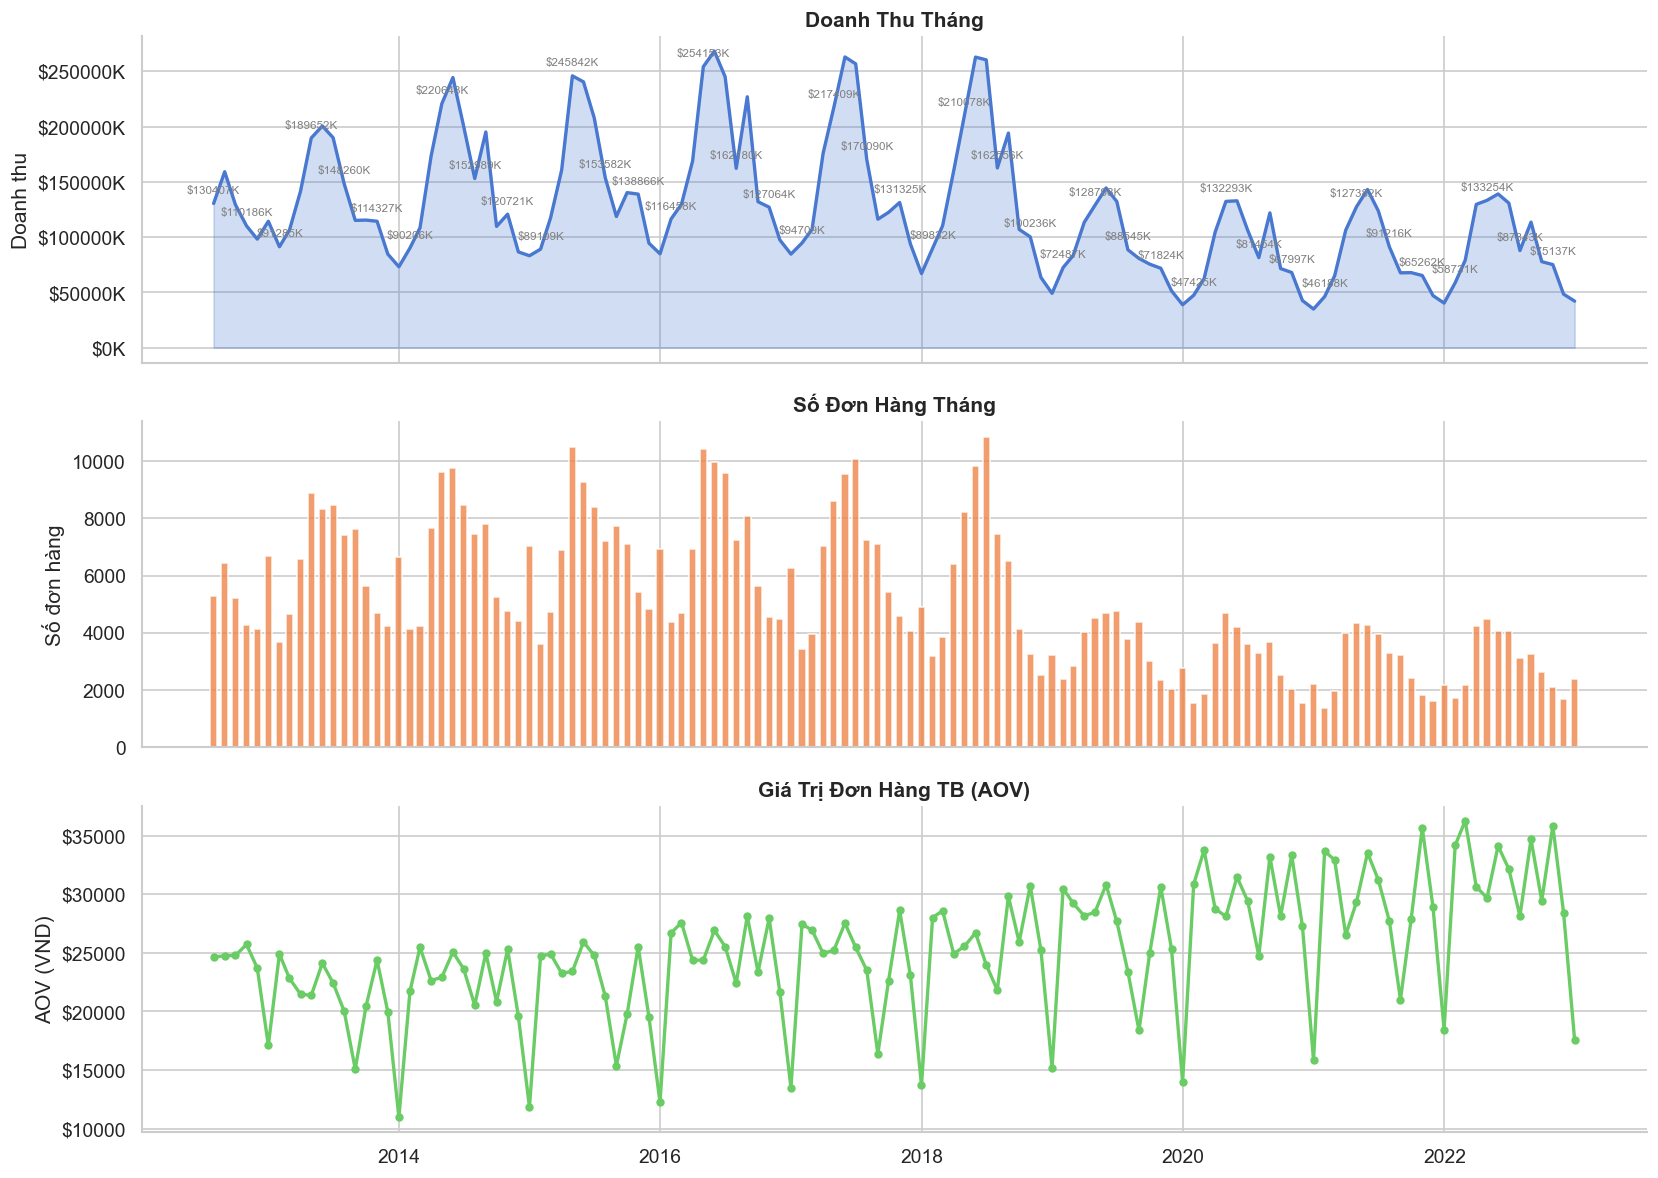

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Revenue
axes[0].fill_between(monthly_rev.index, monthly_rev['revenue'],
                     alpha=0.25, color=PALETTE[0])
axes[0].plot(monthly_rev.index, monthly_rev['revenue'],
             color=PALETTE[0], linewidth=2)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].set_ylabel('Doanh thu')
axes[0].set_title('Doanh Thu Tháng', fontweight='bold')
for i, (d, v) in enumerate(monthly_rev['revenue'].items()):
    if i % 3 == 0:
        axes[0].annotate(f'${v/1e3:.0f}K', (d, v),
                         textcoords='offset points', xytext=(0,6),
                         ha='center', fontsize=7, color='gray')

# Orders
axes[1].bar(monthly_rev.index, monthly_rev['orders'],
            width=20, color=PALETTE[1], alpha=0.8)
axes[1].set_ylabel('Số đơn hàng')
axes[1].set_title('Số Đơn Hàng Tháng', fontweight='bold')

# AOV
axes[2].plot(monthly_rev.index, monthly_rev['aov'],
             color=PALETTE[2], linewidth=2, marker='o', markersize=4)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}'))
axes[2].set_ylabel('AOV (VND)')
axes[2].set_title('Giá Trị Đơn Hàng TB (AOV)', fontweight='bold')


plt.tight_layout()
plt.show()

Mặc dù cả doanh thu lận lượng đơn đều giảm nhưng AOV vẫn tăng -> có thể nhiều đơn hàng lớn hơn

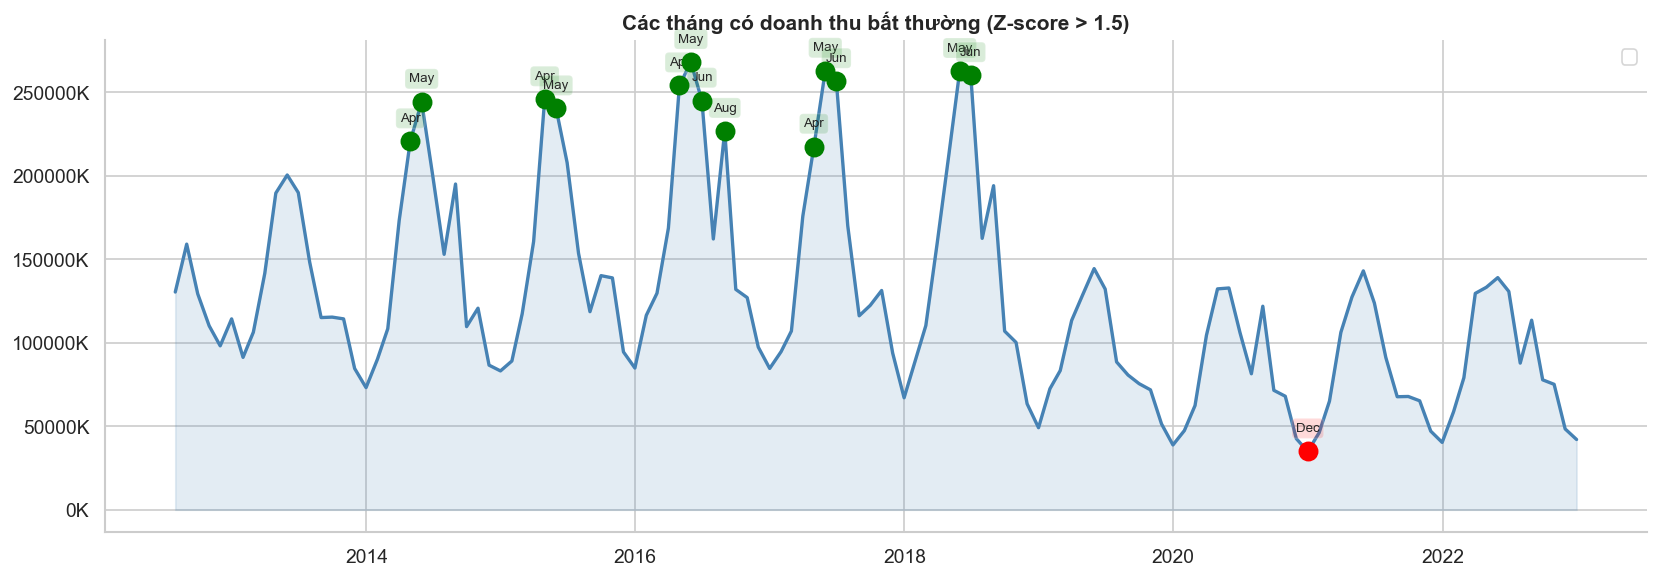


Các tháng bất thường:
                 revenue  orders           aov             type   z_score
order_date                                                               
2014-04-30  2.206425e+08    9627  22919.135986  ▲ Đột biến tăng  1.677512
2014-05-31  2.443095e+08    9744  25072.818383  ▲ Đột biến tăng  2.090250
2015-04-30  2.458423e+08   10502  23409.093510  ▲ Đột biến tăng  2.116980
2015-05-31  2.403847e+08    9273  25923.076266  ▲ Đột biến tăng  2.021803
2016-04-30  2.541533e+08   10426  24376.872711  ▲ Đột biến tăng  2.261918
2016-05-31  2.681319e+08    9965  26907.364136  ▲ Đột biến tăng  2.505696
2016-06-30  2.449944e+08    9595  25533.551848  ▲ Đột biến tăng  2.102194
2016-08-31  2.269003e+08    8065  28133.944113  ▲ Đột biến tăng  1.786643
2017-04-30  2.174093e+08    8619  25224.420390  ▲ Đột biến tăng  1.621127
2017-05-31  2.629088e+08    9553  27521.076715  ▲ Đột biến tăng  2.414610
2017-06-30  2.566675e+08   10078  25468.101296  ▲ Đột biến tăng  2.305765
2018-05-31  2.6

In [7]:
from datetime import datetime
# Z-score để phát hiện tháng doanh thu bất thường
rev_z = stats.zscore(monthly_rev['revenue'])
anomalies = monthly_rev[np.abs(rev_z) > 1.5].copy()
anomalies['z_score'] = rev_z[np.abs(rev_z) > 1.5]
anomalies['type'] = anomalies['z_score'].apply(lambda z: '▲ Đột biến tăng' if z > 0 else '▼ Đột biến giảm')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_rev.index, monthly_rev['revenue'], color='steelblue', linewidth=2)
ax.fill_between(monthly_rev.index, monthly_rev['revenue'], alpha=0.15, color='steelblue')

# Đánh dấu bất thường
for idx, row in anomalies.iterrows():
    color = 'red' if row['z_score'] < 0 else 'green'
    ax.scatter(idx, row['revenue'], s=120, color=color, zorder=5)
    ax.annotate(
        f"{datetime.strftime(idx, '%b')}",
        (idx, row['revenue']),
        textcoords='offset points', xytext=(0, 12),
        ha='center', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc=color, alpha=0.15)
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
ax.set_title('Các tháng có doanh thu bất thường (Z-score > 1.5)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCác tháng bất thường:')
print(anomalies[['revenue','orders','aov','type','z_score']].to_string())

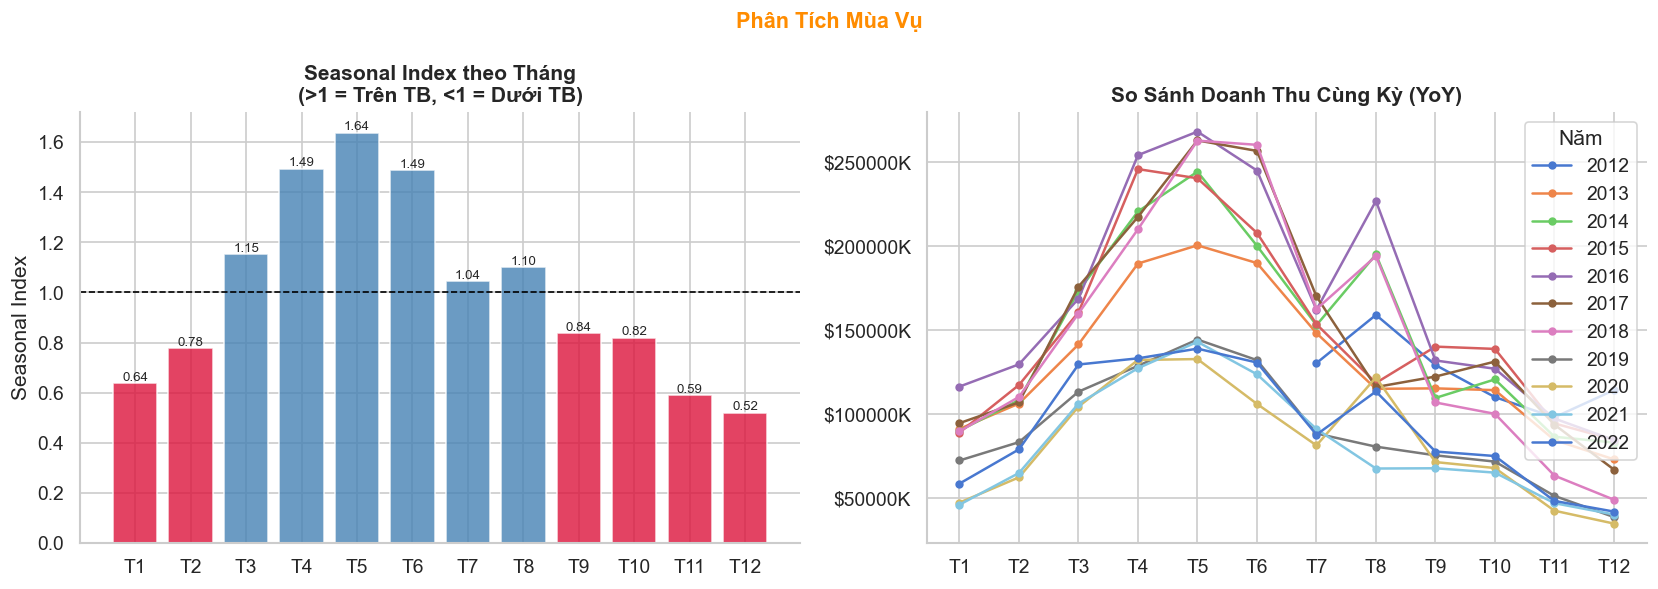

Tháng cao điểm  : [5, 4, 6]
Tháng thấp điểm : [12, 11, 1]


In [8]:
# Seasonality index = tháng TB / tổng TB
monthly_rev['month'] = monthly_rev.index.month
monthly_rev['year']  = monthly_rev.index.year
seasonal_idx = (
    monthly_rev.groupby('month')['revenue'].mean() /
    monthly_rev['revenue'].mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Seasonality index bar
colors = ['crimson' if v < 1 else 'steelblue' for v in seasonal_idx]
axes[0].bar(range(1,13), seasonal_idx.values, color=colors, alpha=0.8)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['T1','T2','T3','T4','T5','T6',
                          'T7','T8','T9','T10','T11','T12'])
axes[0].set_title('Seasonal Index theo Tháng\n(>1 = Trên TB, <1 = Dưới TB)',
                  fontweight='bold')
axes[0].set_ylabel('Seasonal Index')
for i, v in enumerate(seasonal_idx.values):
    axes[0].text(i+1, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

# Year-over-year overlay
for yr, grp in monthly_rev.groupby('year'):
    axes[1].plot(grp['month'], grp['revenue'],
                 marker='o', markersize=4, label=str(yr))
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['T1','T2','T3','T4','T5','T6',
                          'T7','T8','T9','T10','T11','T12'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1].set_title('So Sánh Doanh Thu Cùng Kỳ (YoY)', fontweight='bold')
axes[1].legend(title='Năm')

plt.suptitle('Phân Tích Mùa Vụ',
             fontsize=13, fontweight='bold', color='darkorange')
plt.tight_layout()
plt.show()

top_months = seasonal_idx.nlargest(3).index.tolist()
low_months = seasonal_idx.nsmallest(3).index.tolist()
print(f'Tháng cao điểm  : {top_months}')
print(f'Tháng thấp điểm : {low_months}')

Doanh thu có tính mùa vụ, cao điểm vào t4-t6 -> chu kỳ xuân hè mạnh. 
Tất cả các tháng đột biến tăng (chấm xanh) đều rơi vào tháng 4, 5, 6 —> xác nhận mùa vụ, nhưng cũng cho thấy có yếu tố khuếch đại (campaign lớn? sự kiện đặc biệt?) làm một số năm vượt xa trung bình. 

Điểm đột biến giảm duy nhất là tháng 12/2021 (chấm đỏ) —> bất thường vì T12 vốn đã là đáy mùa vụ, nhưng năm đó còn thấp hơn cả mức đáy bình thường.

# 3. Phân Rã Theo Danh Mục & Kênh

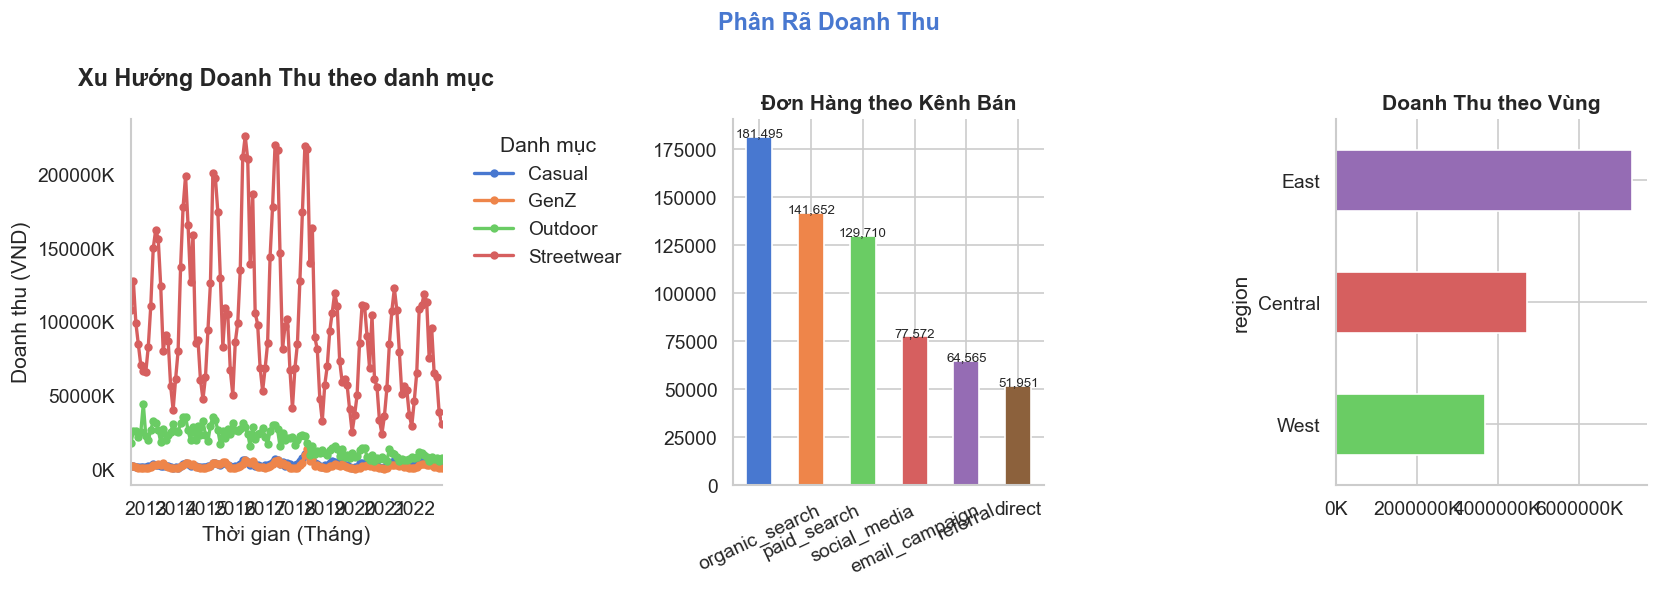

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Revenue by category
df_trend = (
    order_items
    .merge(products[['product_id', 'category']], on='product_id')
    .merge(orders[['order_id', 'order_date']], on='order_id')
)
df_trend['order_date'] = pd.to_datetime(df_trend['order_date'])

cat_trend_data = (
    df_trend
    .groupby([pd.Grouper(key='order_date', freq='ME'), 'category'])['line_rev']
    .sum()
    .unstack()
    .fillna(0)
)
cat_trend_data.plot(kind='line', ax=axes[0], marker='o', markersize=4, linewidth=2)

axes[0].set_title('Xu Hướng Doanh Thu theo danh mục', fontweight='bold', fontsize=14, pad=20)
axes[0].set_xlabel('Thời gian (Tháng)')
axes[0].set_ylabel('Doanh thu (VND)')

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].legend(title='Danh mục', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

axes[0].yaxis.grid(False)
axes[0].xaxis.grid(False)

plt.tight_layout()


# Orders by source
src = orders_full['order_source'].value_counts()
src.plot.bar(ax=axes[1], color=PALETTE, rot=25)
axes[1].set_title('Đơn Hàng theo Kênh Bán', fontweight='bold')
axes[1].set_xlabel('')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=8)

# Revenue by region
reg_rev = orders_full.groupby('region')['revenue'].sum().sort_values()
reg_rev.plot.barh(ax=axes[2], color=PALETTE[2:])
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[2].set_title('Doanh Thu theo Vùng', fontweight='bold')

plt.suptitle('Phân Rã Doanh Thu',
             fontsize=14, fontweight='bold', color=PALETTE[0])
plt.tight_layout()
plt.show()

Streetwear áp đảo -> category nổi bật nhất -> Streetwear chi phối doanh thu và có xu hướng mùa vụ tương tự.   
Organic search dẫn đầu.
3 kênh đầu chiếm ~68% tổng đơn hàng


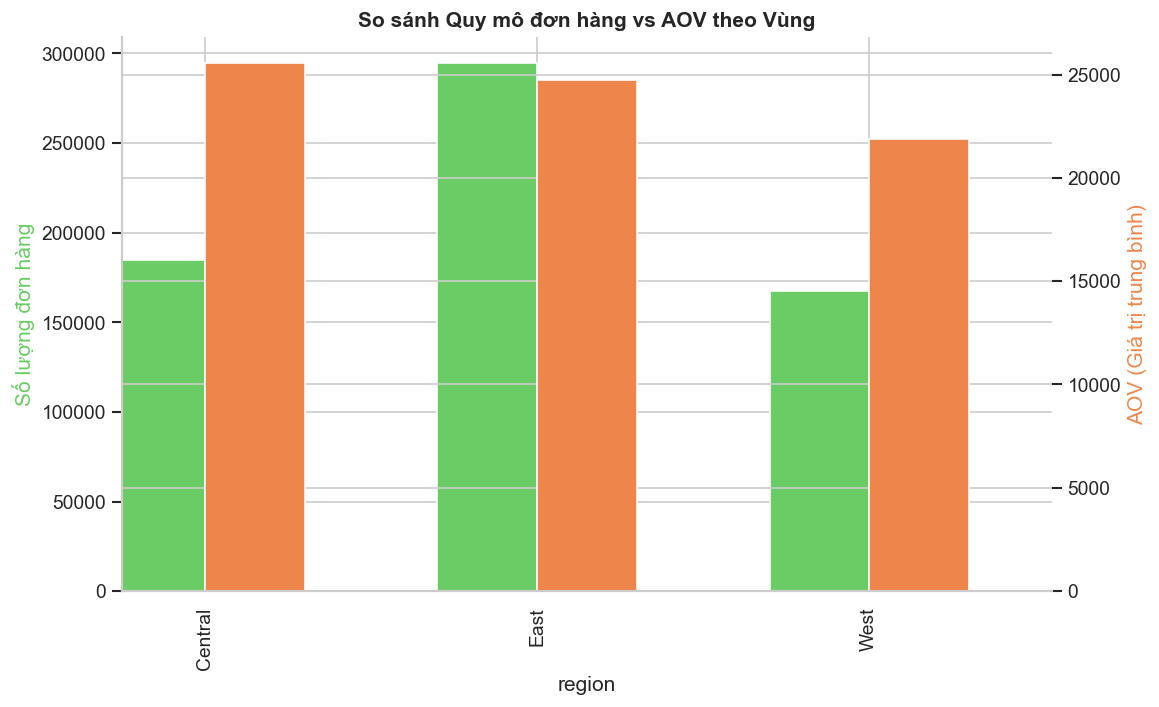

In [67]:
region_stats = (
    orders_full
    .groupby('region')
    .agg(n_orders=('order_id', 'nunique'), 
         revenue=('revenue', 'sum'))
)
region_stats['aov'] = region_stats['revenue'] / region_stats['n_orders']

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

region_stats['n_orders'].plot(kind='bar', ax=ax1, color=PALETTE[2], position=1, width=0.3, label='Số đơn hàng')
region_stats['aov'].plot(kind='bar', ax=ax2, color=PALETTE[1], position=0, width=0.3, label='AOV')

ax1.set_ylabel('Số lượng đơn hàng', color=PALETTE[2])
ax2.set_ylabel('AOV (Giá trị trung bình)', color=PALETTE[1])
plt.title('So sánh Quy mô đơn hàng vs AOV theo Vùng', fontweight='bold')
plt.show()

East là thị trường chủ yếu, có doanh thu cao nhờ cả số lượng đơn và có giá trị đơn nhưng central cũng rất tiềm năng (aov cao nhất).

# 4. Phân tích khách hàng

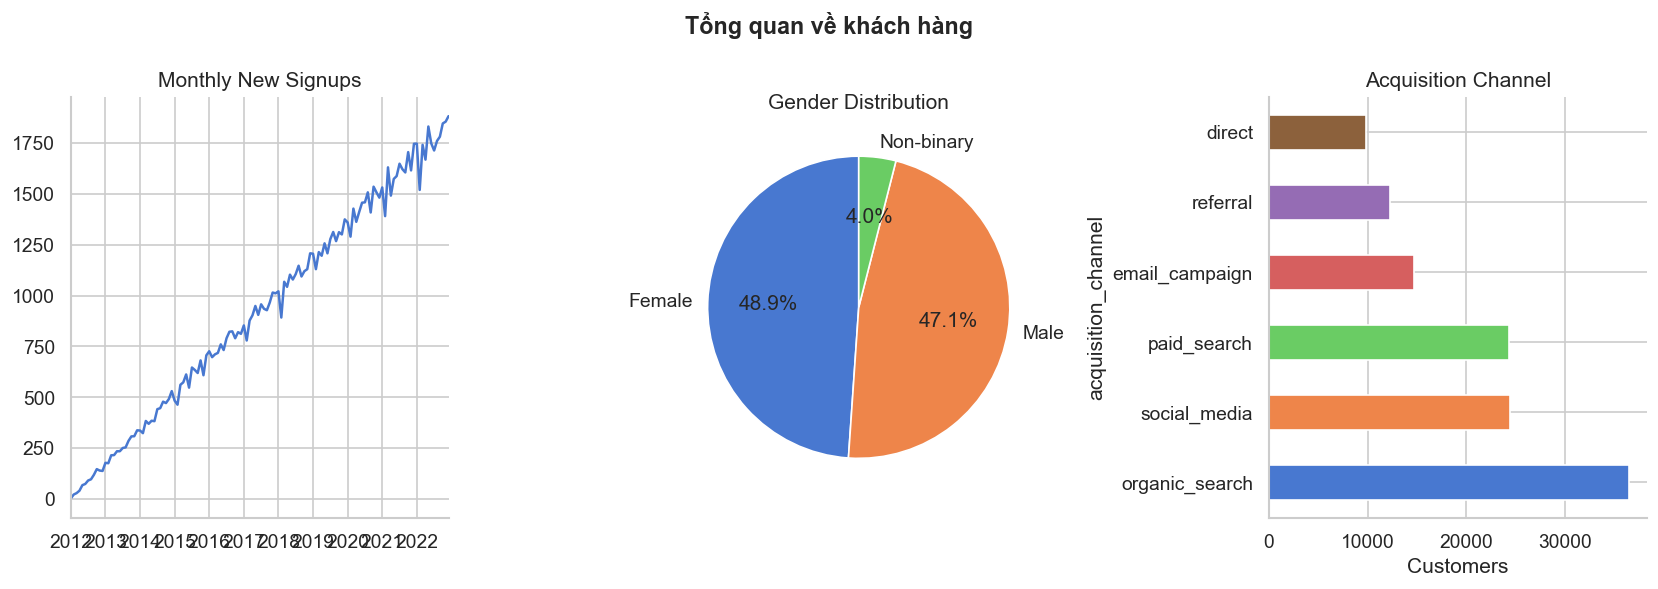

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Signups over time
customers.set_index('signup_date').resample('M')['customer_id'].count().plot(
    ax=axes[0], color=PALETTE[0])
axes[0].set_title('Monthly New Signups')
axes[0].set_xlabel('')


# monthly_avg = (
#     customers
#     .set_index('signup_date')
#     .resample('ME')['customer_id']
#     .count()
#     .groupby(lambda d: d.month)
#     .median()
# )

# # Plot average signups for each calendar month
# monthly_avg.plot.bar(ax=axes[0], color=PALETTE[0])
# axes[0].set_title('Average Monthly Signups')
# axes[0].set_xlabel('')
# axes[0].set_xticks(range(0, 13))

# axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])


# Gender split
customers['gender'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=PALETTE[:customers['gender'].nunique()])
axes[1].set_ylabel('')
axes[1].set_title('Gender Distribution')

# Acquisition channel
ch = customers['acquisition_channel'].value_counts()
ch.plot.barh(ax=axes[2], color=PALETTE)
axes[2].set_title('Acquisition Channel')
axes[2].set_xlabel('Customers')

plt.suptitle('Tổng quan về khách hàng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


One-time buyers : 24.8%
Repeat buyers   : 75.2%
Median orders/cust: 4.00


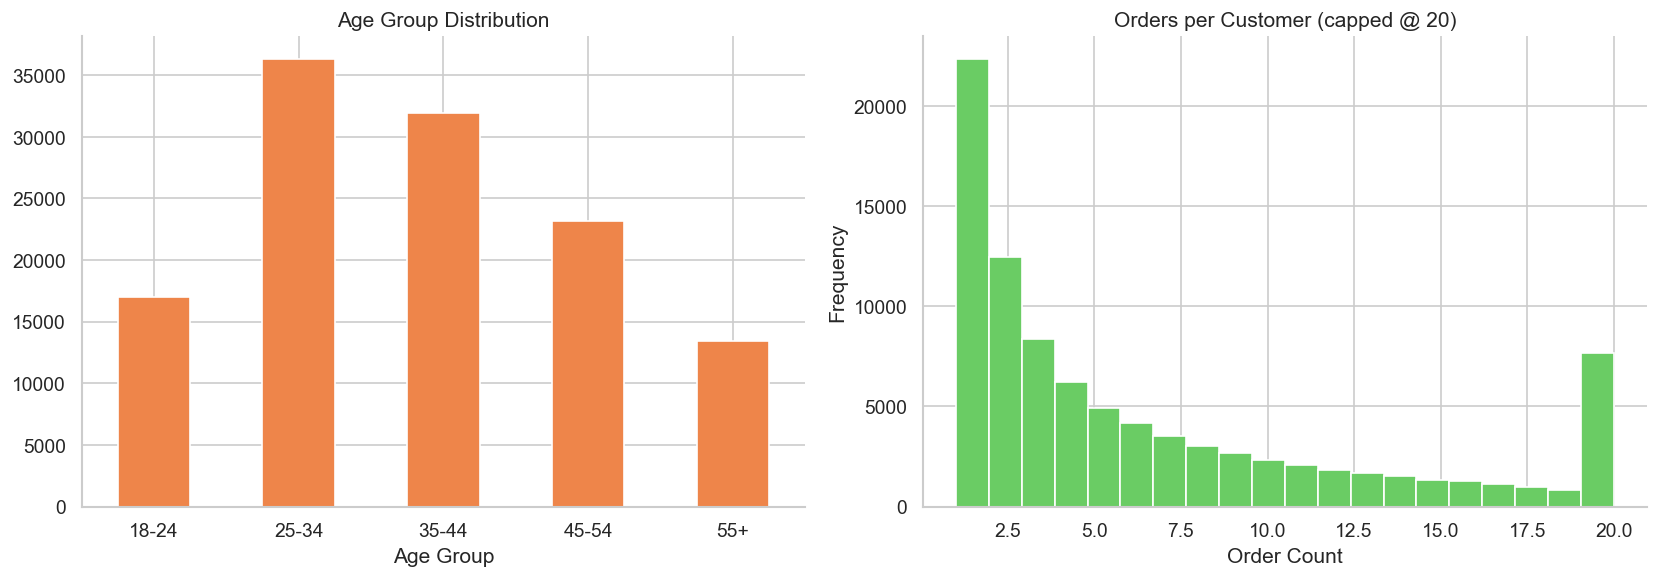

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age group
age_order = sorted(customers['age_group'].dropna().unique())
customers['age_group'].value_counts().reindex(age_order).plot.bar(
    ax=axes[0], color=PALETTE[1], rot=0)
axes[0].set_title('Age Group Distribution')
axes[0].set_xlabel('Age Group')

# Orders per customer
opc = orders.groupby('customer_id').size()
opc.clip(upper=20).plot.hist(bins=20, ax=axes[1], color=PALETTE[2], edgecolor='white')
axes[1].set_title('Orders per Customer (capped @ 20)')
axes[1].set_xlabel('Order Count')

print(f'One-time buyers : {(opc == 1).mean():.1%}')
print(f'Repeat buyers   : {(opc  > 1).mean():.1%}')
print(f'Median orders/cust: {opc.median():.2f}') # do bị ảnh hưởng nhiều bởi các đơn đột biến

plt.tight_layout()
plt.show()

Phần lớn tệp khách hàng trẻ -> chủ yếu dưới 34

In [12]:
ltv = (
    cus_seg
    .groupby('customer_id')['revenue'].sum()
    .reset_index()
    .rename(columns={'revenue': 'ltv'})
)
print(f"LTV trung bình hiện tại: {ltv['ltv'].mean():,.0f} VND")

LTV trung bình hiện tại: 173,757 VND


In [13]:
n_orders = orders['order_id'].nunique()
n_cust = orders['customer_id'].nunique()
total_rev = order_items['line_rev'].sum()

aov = total_rev / n_orders
purchase_freq = n_orders / n_cust

# Giả định Customer Lifespan = 2 năm
lifespan_years = 2

# 2. Tính CLTV
cltv = aov * purchase_freq * lifespan_years

print(f"AOV: {aov:,.0f} VND")
print(f"Tần suất mua hàng: {purchase_freq:.2f} đơn/khách")
print(f"CLTV ({lifespan_years} năm): {cltv:,.0f} VND")

AOV: 24,238 VND
Tần suất mua hàng: 7.17 đơn/khách
CLTV (2 năm): 347,514 VND


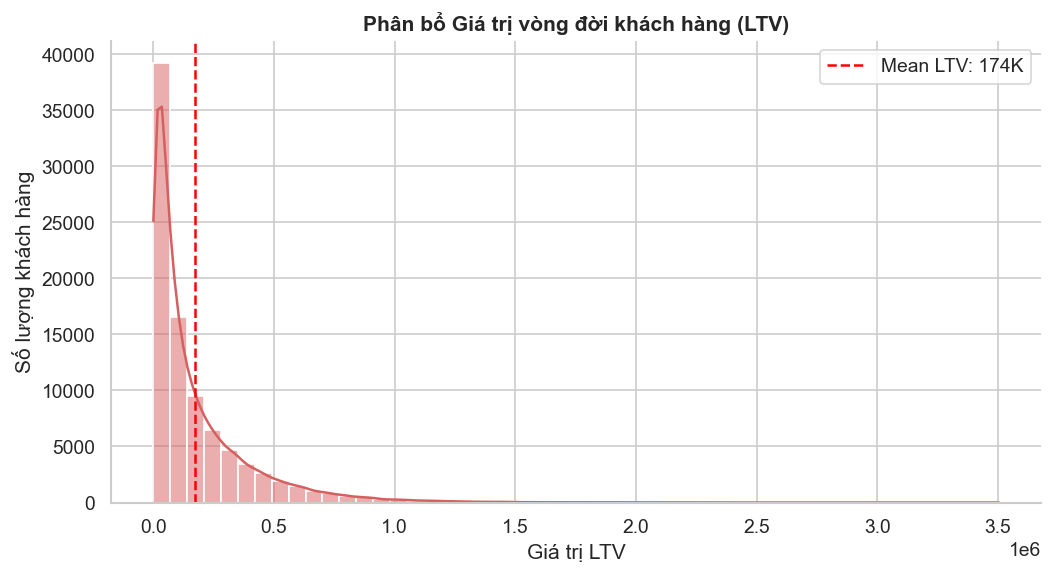

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(ltv['ltv'], bins=50, kde=True, color=PALETTE[3])
plt.axvline(ltv['ltv'].mean(), color='red', linestyle='--', label=f'Mean LTV: {ltv["ltv"].mean()/1e3:.0f}K')
plt.title('Phân bổ Giá trị vòng đời khách hàng (LTV)', fontweight='bold')
plt.xlabel('Giá trị LTV')
plt.ylabel('Số lượng khách hàng')
plt.legend()
plt.show()

High freq, low AOV.  
Có những khách hàng với số đơn hàng lên tới hơn 40-50 lần (phía cuối đuôi bên phải). kéo chỉ số trung bình (Mean orders/cust = 7.17) lên cao, dù số lượng kh này rất ít.

Ngưỡng để trở thành top 5%: >= 24 đơn hàng
Tỷ lệ số lượng khách trong top 5%: 5.5%
Tỷ lệ doanh thu đóng góp: 25.5%


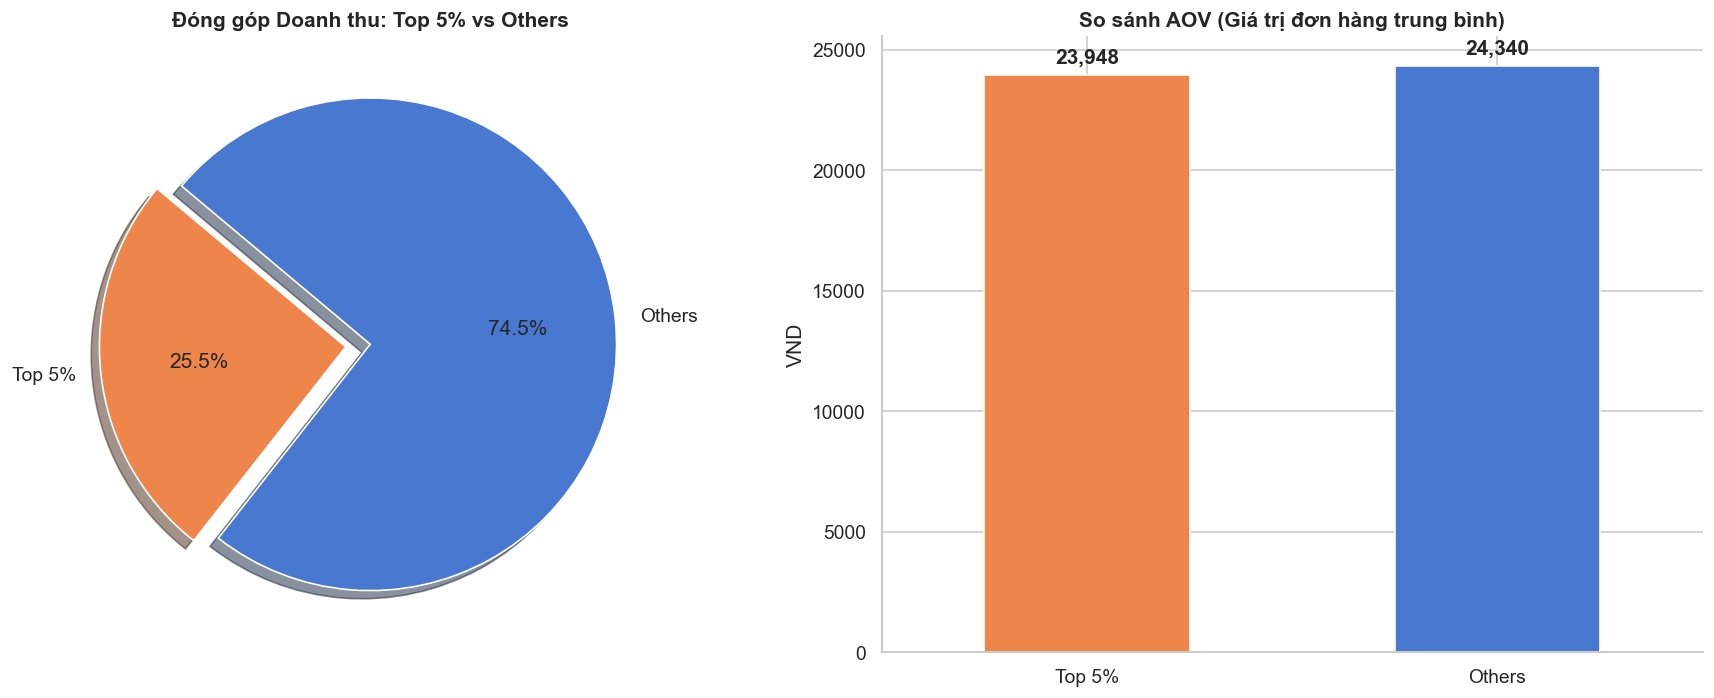

In [164]:
# 1. Tính toán tần suất và doanh thu theo từng khách hàng
cust_summary = (
    order_items.merge(orders[['order_id', 'customer_id']], on='order_id')
    .groupby('customer_id')
    .agg(
        frequency=('order_id', 'nunique'),
        monetary=('line_rev', 'sum')
    )
)

# Top 5% khách hàng mua nhiều nhất
top_threshold = cust_summary['frequency'].quantile(0.95)
super_fans = cust_summary[cust_summary['frequency'] >= top_threshold]
others = cust_summary[cust_summary['frequency'] < top_threshold]

# Tính toán tỷ trọng đóng góp
total_rev = cust_summary['monetary'].sum()
sf_rev_share = (super_fans['monetary'].sum() / total_rev) * 100
sf_count_share = (len(super_fans) / len(cust_summary)) * 100

print(f"Ngưỡng để trở thành top 5%: >= {top_threshold:.0f} đơn hàng")
print(f"Tỷ lệ số lượng khách trong top 5%: {sf_count_share:.1f}%")
print(f"Tỷ lệ doanh thu đóng góp: {sf_rev_share:.1f}%")
labels = ['Top 5%', 'Others']
rev_shares = [sf_rev_share, 100 - sf_rev_share]
customer_counts = [len(super_fans), len(others)]

# Tính AOV trung bình của từng nhóm để so sánh chất lượng đơn hàng
sf_aov = super_fans['monetary'].sum() / super_fans['frequency'].sum()
others_aov = others['monetary'].sum() / others['frequency'].sum()

# 2. Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ tròn: Tỷ trọng doanh thu
axes[0].pie(rev_shares, labels=labels, autopct='%1.1f%%', startangle=140, 
            colors=[PALETTE[1], PALETTE[0]], explode=(0.1, 0), shadow=True)
axes[0].set_title('Đóng góp Doanh thu: Top 5% vs Others', fontweight='bold')

# Biểu đồ cột: So sánh AOV
aov_comparison = pd.Series([sf_aov, others_aov], index=labels)
aov_comparison.plot(kind='bar', ax=axes[1], color=[PALETTE[1], PALETTE[0]])
axes[1].set_title('So sánh AOV (Giá trị đơn hàng trung bình)', fontweight='bold')
axes[1].set_ylabel('VND')
axes[1].set_xticklabels(labels, rotation=0)

# Thêm số liệu trực tiếp trên đầu cột AOV
for i, v in enumerate([sf_aov, others_aov]):
    axes[1].text(i, v + 500, f'{v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Chỉ hơn 5% khách hàng có tỷ lệ đóng góp doanh thu tới gần 26%. Tuy nhiên thì AOV không có sự khác biệt quá nhiều -> LTV lớn nhờ tần suất mua.

### Mất bao lâu kể từ ngày signup để mua đơn hàng đầu tiên?

Text(0.5, 1.0, 'Distribution of Time to First Order (days)')

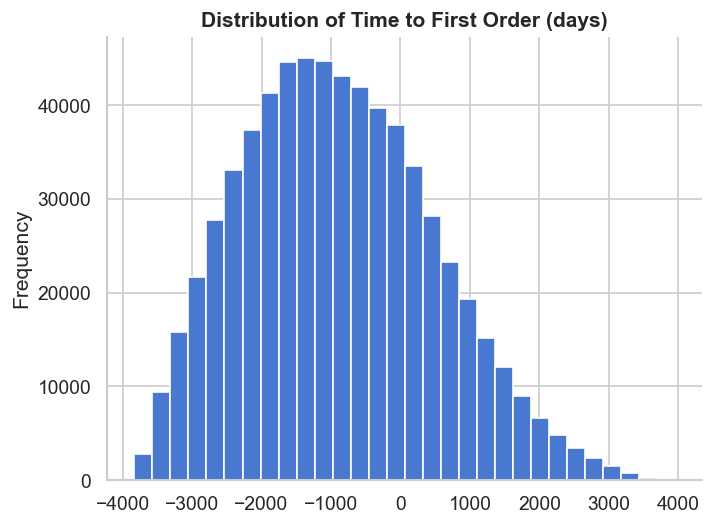

In [11]:
cus_seg['time_to_first_order'] = (cus_seg['order_date'] - cus_seg['signup_date']).dt.days
cus_seg['time_to_first_order'].plot.hist(bins=30, edgecolor='white')
plt.title('Distribution of Time to First Order (days)', fontweight='bold')

### So Sánh Phân Khúc — Khách Hàng Mới vs Quay Lại

In [15]:
seg_monthly_count = (
    orders_seg
    .set_index('order_date')
    .groupby([pd.Grouper(freq='ME'), 'segment'])['customer_id']
    .count()
    .unstack('segment')
    .fillna(0)
)
seg_monthly_count

segment,Khách mới,Khách quay lại
order_date,,
2012-07-31,4921,373
2012-08-31,5176,1251
2012-09-30,3641,1578
2012-10-31,2653,1632
2012-11-30,2298,1844
...,...,...
2022-08-31,132,3142
2022-09-30,93,2550
2022-10-31,52,2045


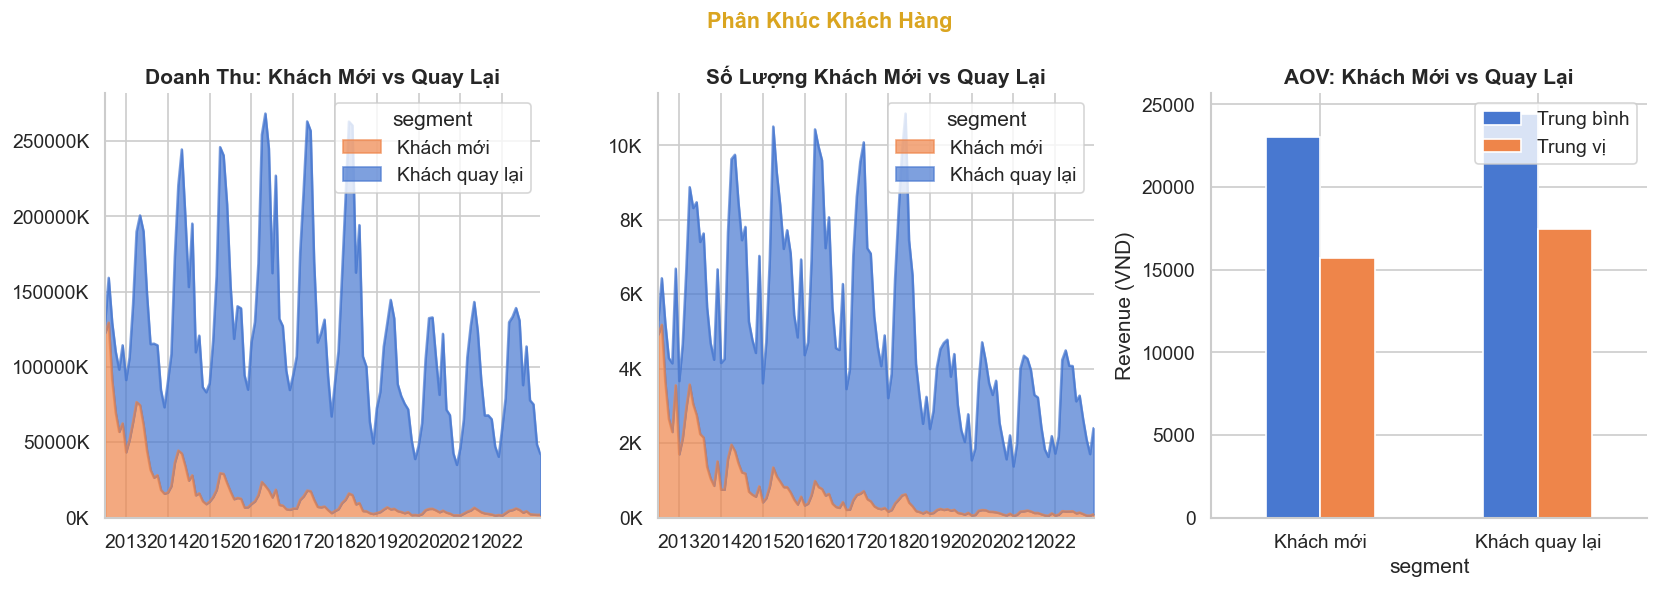

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Stacked area
seg_monthly.plot.area(ax=axes[0], alpha=0.7, color=[PALETTE[1], PALETTE[0]])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[0].set_title('Doanh Thu: Khách Mới vs Quay Lại', fontweight='bold')
axes[0].set_xlabel('')

seg_monthly_count.plot.area(ax=axes[1], alpha=0.7, color=[PALETTE[1], PALETTE[0]])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
axes[1].set_title('Số Lượng Khách Mới vs Quay Lại', fontweight='bold')
axes[1].set_xlabel('')

# AOV comparison
seg_aov = orders_seg.groupby('segment')['revenue'].agg(['mean','median'])
seg_aov[['mean','median']].plot.bar(ax=axes[2], color=[PALETTE[0], PALETTE[1]], rot=0)
axes[2].set_title('AOV: Khách Mới vs Quay Lại', fontweight='bold')
axes[2].set_ylabel('Revenue (VND)')
axes[2].legend(['Trung bình','Trung vị'])

plt.suptitle('Phân Khúc Khách Hàng',
             fontsize=13, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

                    n_customers  avg_recency  avg_freq  avg_monetary     total_rev  pct_customers  pct_revenue
segment                                                                                                       
Champions                 23423        260.0      17.2      427426.2  1.001160e+10       0.259546     0.638460
Loyal                     17261        754.9       7.4      180487.3  3.115390e+09       0.191266     0.198675
Cant Lose Them             8111       1976.8       4.1       83858.1  6.801728e+08       0.089877     0.043376
At Risk                    2281       1739.3       9.2      231983.3  5.291540e+08       0.025275     0.033745
Lost                      22367       2538.9       1.3       21975.2  4.915195e+08       0.247845     0.031345
Needs Attention            6510       1719.0       1.5       66715.1  4.343156e+08       0.072136     0.027697
New Customers              4869        341.3       1.6       44627.8  2.172927e+08       0.053953     0.013857
P

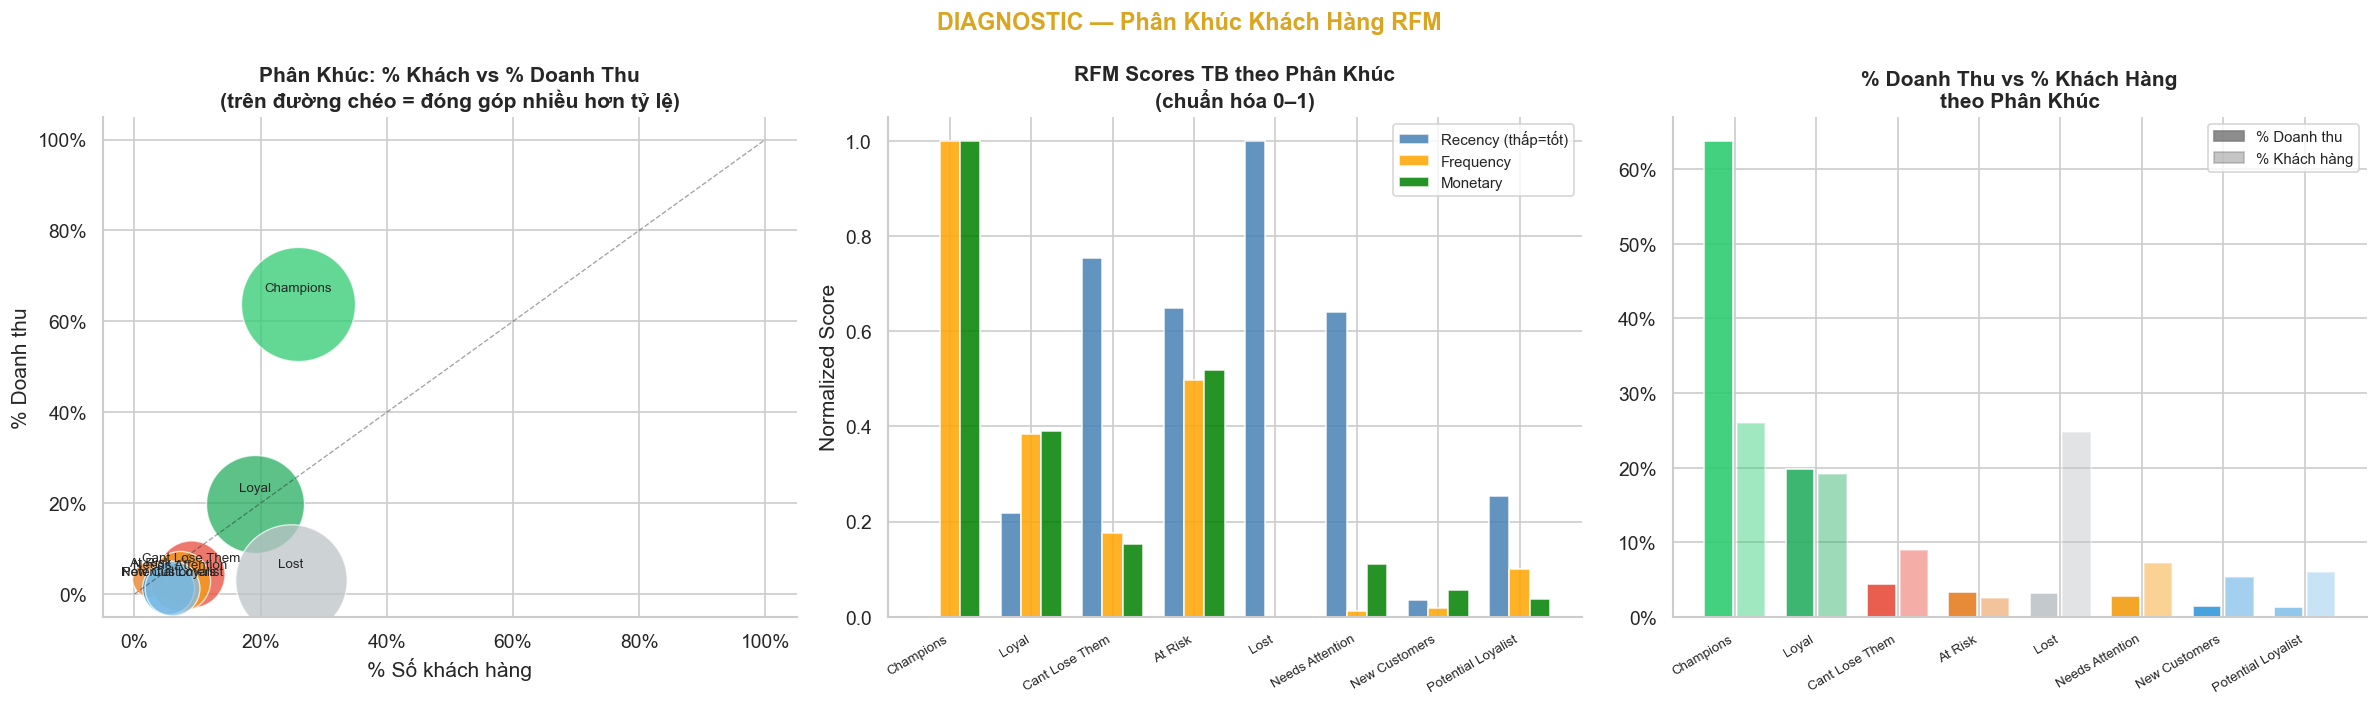

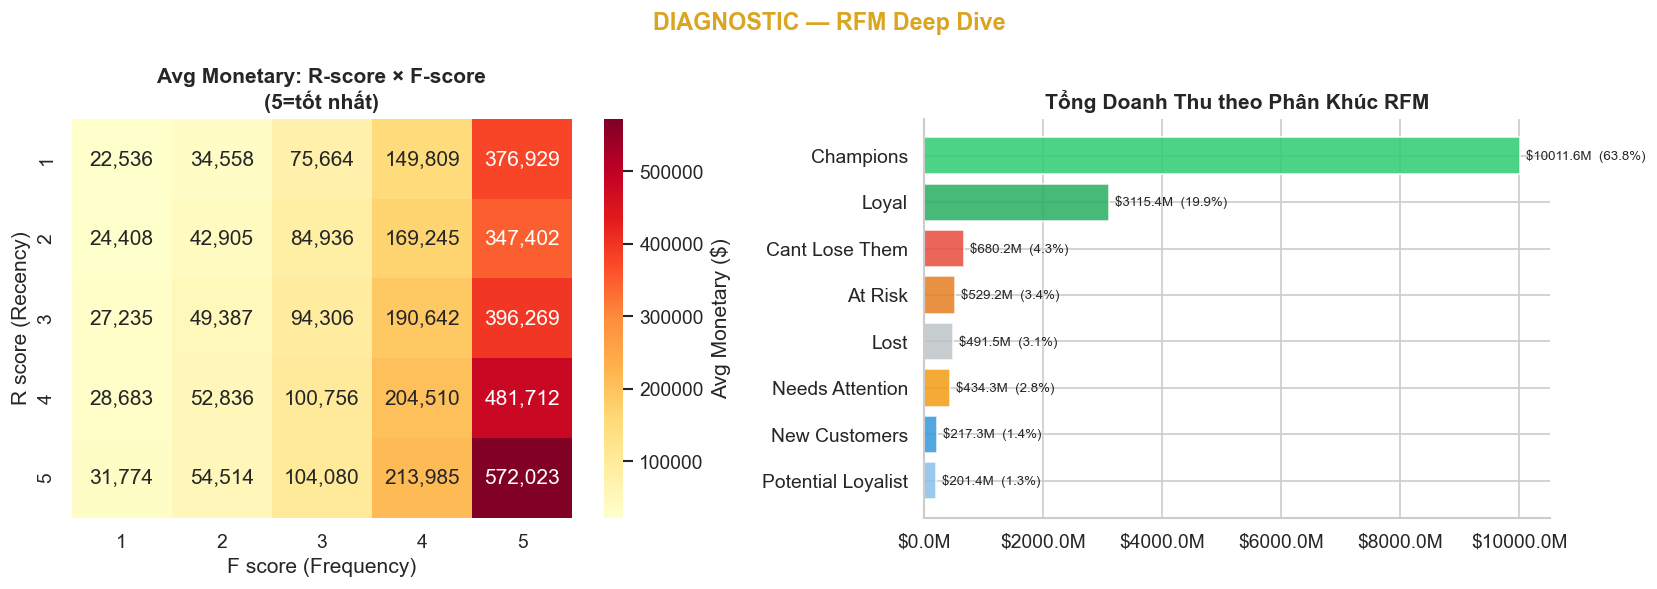

In [ ]:

# ── RFM Scoring (1–5, recency: thấp hơn = tốt hơn) ──────────────────────────
rfm['R'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),
                   q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_total'] = rfm[['R','F','M']].sum(axis=1)

# ── Segment mapping ───────────────────────────────────────────────────────────
def segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(segment, axis=1)

# ── Segment summary ───────────────────────────────────────────────────────────
seg_summary = (
    rfm.groupby('segment')
    .agg(
        n_customers = ('customer_id', 'count'),
        avg_recency = ('recency',     'mean'),
        avg_freq    = ('frequency',   'mean'),
        avg_monetary= ('monetary',    'mean'),
        total_rev   = ('monetary',    'sum'),
    )
    .round(1)
    .sort_values('total_rev', ascending=False)
)
seg_summary['pct_customers'] = seg_summary['n_customers'] / seg_summary['n_customers'].sum()
seg_summary['pct_revenue']   = seg_summary['total_rev']   / seg_summary['total_rev'].sum()

print(seg_summary.to_string())

# ── Plot 1: Segment size & revenue share ─────────────────────────────────────
SEG_COLORS = {
    'Champions'         : '#2ecc71',
    'Loyal'             : '#27ae60',
    'New Customers'     : '#3498db',
    'Potential Loyalist': '#85c1e9',
    'At Risk'           : '#e67e22',
    'Cant Lose Them'    : '#e74c3c',
    'Needs Attention'   : '#f39c12',
    'Lost'              : '#bdc3c7',
}
seg_order = seg_summary.index.tolist()
colors    = [SEG_COLORS.get(s, 'gray') for s in seg_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Bubble: pct_customers vs pct_revenue
ax = axes[0]
for seg, row in seg_summary.iterrows():
    ax.scatter(row['pct_customers'], row['pct_revenue'],
               s=row['n_customers']/5,
               color=SEG_COLORS.get(seg,'gray'), alpha=0.75,
               edgecolors='white', linewidth=0.8)
    ax.annotate(seg,
                (row['pct_customers'], row['pct_revenue']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.4)   # diagonal reference
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xlabel('% Số khách hàng')
ax.set_ylabel('% Doanh thu')
ax.set_title('Phân Khúc: % Khách vs % Doanh Thu\n(trên đường chéo = đóng góp nhiều hơn tỷ lệ)',
             fontweight='bold')

# Grouped bar: avg recency / freq / monetary (normalized)
ax = axes[1]
metrics = seg_summary[['avg_recency','avg_freq','avg_monetary']].copy()
metrics_norm = (metrics - metrics.min()) / (metrics.max() - metrics.min())
x  = np.arange(len(seg_order))
w  = 0.25
ax.bar(x - w,   metrics_norm.loc[seg_order,'avg_recency'],
       width=w, color='steelblue', alpha=0.85, label='Recency (thấp=tốt)')
ax.bar(x,       metrics_norm.loc[seg_order,'avg_freq'],
       width=w, color='orange',    alpha=0.85, label='Frequency')
ax.bar(x + w,   metrics_norm.loc[seg_order,'avg_monetary'],
       width=w, color='green',     alpha=0.85, label='Monetary')
ax.set_xticks(x)
ax.set_xticklabels(seg_order, rotation=30, ha='right', fontsize=8)
ax.set_title('RFM Scores TB theo Phân Khúc\n(chuẩn hóa 0–1)', fontweight='bold')
ax.set_ylabel('Normalized Score')
ax.legend(fontsize=9)

# Stacked bar: revenue & customer share side by side
ax = axes[2]
x3 = np.arange(len(seg_order))
bottom_rev = bottom_cust = 0
rev_vals  = seg_summary.loc[seg_order,'pct_revenue'].values
cust_vals = seg_summary.loc[seg_order,'pct_customers'].values

bars_rev  = ax.bar(x3 - 0.2, rev_vals,  width=0.35,
                   color=colors, alpha=0.9)
bars_cust = ax.bar(x3 + 0.2, cust_vals, width=0.35,
                   color=colors, alpha=0.45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xticks(x3)
ax.set_xticklabels(seg_order, rotation=30, ha='right', fontsize=8)
ax.set_title('% Doanh Thu vs % Khách Hàng\ntheo Phân Khúc', fontweight='bold')
lines3 = [mpatches.Patch(color='gray', alpha=0.9, label='% Doanh thu'),
          mpatches.Patch(color='gray', alpha=0.45, label='% Khách hàng')]
ax.legend(handles=lines3, fontsize=9)

plt.suptitle('DIAGNOSTIC — Phân Khúc Khách Hàng RFM',
             fontsize=14, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

# ── Plot 2: RFM Heatmap R vs F, colored by avg Monetary ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_rf = rfm.groupby(['R','F'])['monetary'].mean().unstack('F')
sns.heatmap(pivot_rf, annot=True, fmt=',.0f', cmap='YlOrRd',
            cbar_kws={'label':'Avg Monetary ($)'}, ax=axes[0])
axes[0].set_title('Avg Monetary: R-score × F-score\n(5=tốt nhất)', fontweight='bold')
axes[0].set_xlabel('F score (Frequency)')
axes[0].set_ylabel('R score (Recency)')

# Segment treemap-style bar (revenue contribution)
seg_rev_sorted = seg_summary['total_rev'].sort_values(ascending=True)
bar_colors = [SEG_COLORS.get(s,'gray') for s in seg_rev_sorted.index]
axes[1].barh(seg_rev_sorted.index, seg_rev_sorted.values/1e6,
             color=bar_colors, alpha=0.85)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
axes[1].set_title('Tổng Doanh Thu theo Phân Khúc RFM', fontweight='bold')
for bar, val in zip(axes[1].patches, seg_rev_sorted.values):
    pct = val / seg_rev_sorted.sum()
    axes[1].text(bar.get_width() + seg_rev_sorted.max()*0.01/1e6,
                 bar.get_y() + bar.get_height()/2,
                 f'${val/1e6:.1f}M  ({pct:.1%})',
                 va='center', fontsize=8)

plt.suptitle('DIAGNOSTIC — RFM Deep Dive',
             fontsize=14, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

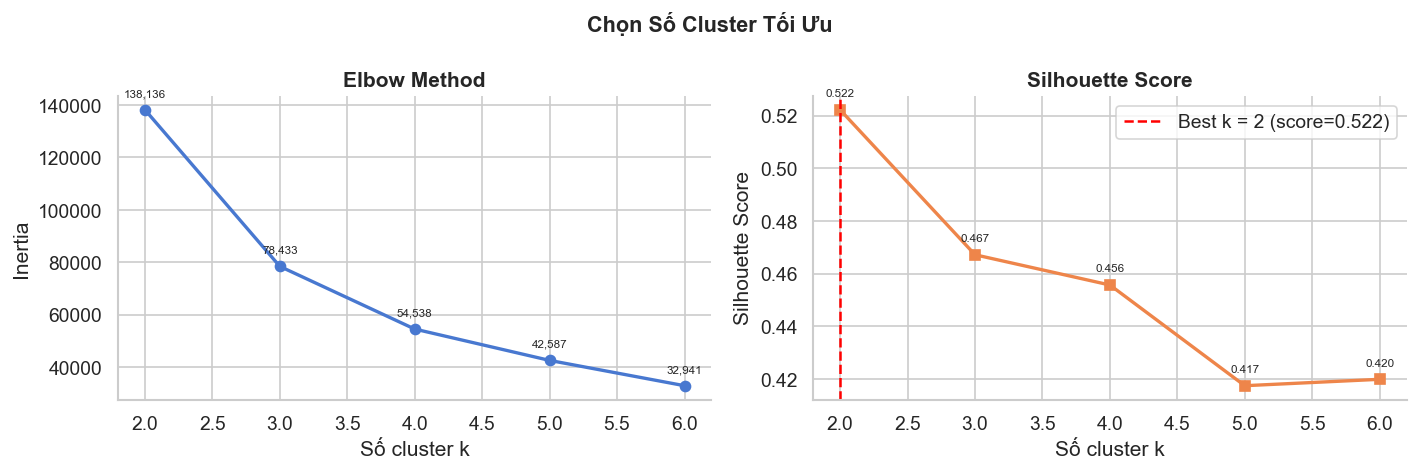


→ Silhouette gợi ý k = 2
  Xem elbow plot để quyết định cuối cùng — chọn điểm "gãy" rõ nhất.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from datetime import timedelta

# ── RFM Calculation ──────────────────────────────────────────────────────────
snapshot_date = orders_full['order_date'].max() + timedelta(days=1)

rfm = (
    orders_full
    .groupby('customer_id')
    .agg(
        recency   = ('order_date',  lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id',    'count'),
        monetary  = ('revenue',     'sum'),
    )
    .reset_index()
)

# ── Chuẩn hóa RFM ────────────────────────────────────────────────────────────
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# ── Elbow + Silhouette để chọn k ─────────────────────────────────────────────
k_range = range(2, 7)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o', color=PALETTE[0], linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Số cluster k')
axes[0].set_ylabel('Inertia')
for k, v in zip(k_range, inertias):
    axes[0].annotate(f'{v:,.0f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=7)

axes[1].plot(k_range, sil_scores, marker='s', color=PALETTE[1], linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Số cluster k')
axes[1].set_ylabel('Silhouette Score')
best_k = k_range[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--',
                label=f'Best k = {best_k} (score={max(sil_scores):.3f})')
axes[1].legend()
for k, v in zip(k_range, sil_scores):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=7)

plt.suptitle('Chọn Số Cluster Tối Ưu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n→ Silhouette gợi ý k = {best_k}')
print('  Xem elbow plot để quyết định cuối cùng — chọn điểm "gãy" rõ nhất.')

In [35]:
# ── Fit KMeans với k được chọn ───────────────────────────────────────────────
K_CHOSEN = 4

km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# ── Cluster profile ───────────────────────────────────────────────────────────
cluster_profile = (
    rfm.groupby('cluster')
    .agg(
        n_customers  = ('customer_id', 'count'),
        avg_recency  = ('recency',     'mean'),
        avg_freq     = ('frequency',   'mean'),
        avg_monetary = ('monetary',    'mean'),
        total_rev    = ('monetary',    'sum'),
    )
    .round(1)
)
cluster_profile['pct_customers'] = (cluster_profile['n_customers'] /
                                     cluster_profile['n_customers'].sum())
cluster_profile['pct_revenue']   = (cluster_profile['total_rev'] /
                                     cluster_profile['total_rev'].sum())

# ── Gán nhãn tự động dựa trên profile ────────────────────────────────────────
# Logic: rank từng chiều rồi gán tên dựa trên pattern
cp = cluster_profile[['avg_recency','avg_freq','avg_monetary']].copy()
cp['R_rank'] = cp['avg_recency'].rank(ascending=True)   # thấp = gần đây = tốt
cp['F_rank'] = cp['avg_freq'].rank(ascending=False)
cp['M_rank'] = cp['avg_monetary'].rank(ascending=False)
cp['overall'] = cp[['R_rank','F_rank','M_rank']].mean(axis=1)

def auto_label(row, n_clusters=4):
    r = row['R_rank']
    f = row['F_rank']
    m = row['M_rank']

    if r == 1 and f == 1 and m == 1:
        return 'Champions'       # tốt cả 3
    elif r >= 3 and f <= 3 and m <= 3:
        return 'At Risk'         # R tệ, từng F+M tốt
    elif r == 4 and f == 4 and m == 4:
        return 'Lost'            # tệ cả 3
    else:
        return 'Loyal'           # còn lại — trung bình khá

cp['label'] = cp.apply(lambda row: auto_label(row, K_CHOSEN), axis=1)
cluster_profile['label'] = cp['label']
rfm['segment'] = rfm['cluster'].map(cp['label'])




print('Cluster Profile:')
print(cluster_profile[['label','n_customers','avg_recency','avg_freq',
                        'avg_monetary','pct_customers','pct_revenue']].to_string())

Cluster Profile:
             label  n_customers  avg_recency  avg_freq  avg_monetary  pct_customers  pct_revenue
cluster                                                                                         
0             Lost        32369       2434.8       2.0       43040.9       0.358675     0.088846
1            Loyal        16694        407.9      15.9      399191.2       0.184983     0.424983
2          At Risk        37293        719.7       4.8      111688.2       0.413237     0.265622
3        Champions         3890        214.5      35.6      889047.7       0.043104     0.220549


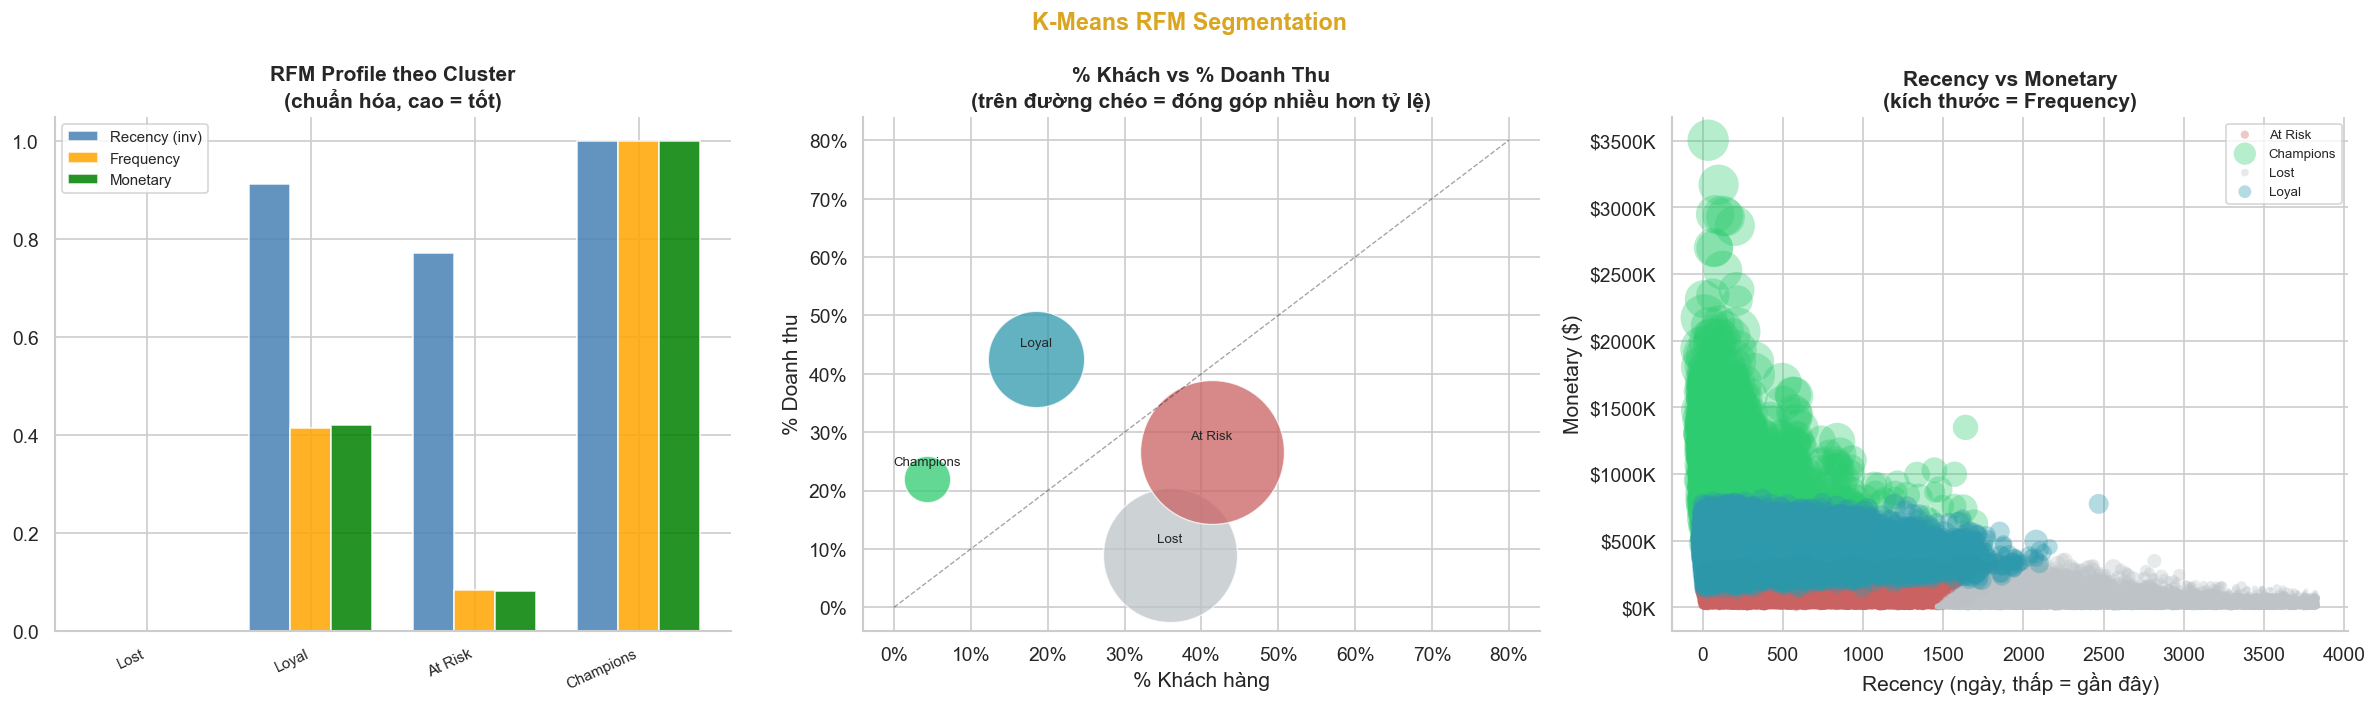

In [36]:
# ── Visualisation ─────────────────────────────────────────────────────────────
SEG_COLORS = {
    'Champions'      : '#2ecc71',
    'Loyal'          : "#2d99ac",
    'At Risk'        : "#ca6262",
    'Lost'           : '#bdc3c7',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Plot 1: Radar / Spider per cluster ───────────────────────────────────────
# Dùng normalized bar thay radar (matplotlib radar cần thêm boilerplate)
metrics_norm = cluster_profile[['avg_recency','avg_freq','avg_monetary']].copy()
# Invert recency: thấp hơn = tốt hơn → flip để bar cao = tốt
metrics_norm['avg_recency'] = metrics_norm['avg_recency'].max() - metrics_norm['avg_recency']
metrics_norm = (metrics_norm - metrics_norm.min()) / \
               (metrics_norm.max() - metrics_norm.min())
metrics_norm.columns = ['Recency (inv)', 'Frequency', 'Monetary']
metrics_norm['label'] = cluster_profile['label'].values

x  = np.arange(len(cluster_profile))
w  = 0.25
bar_colors = [SEG_COLORS.get(l, 'gray') for l in cluster_profile['label']]

axes[0].bar(x - w,  metrics_norm['Recency (inv)'], width=w,
            color='steelblue', alpha=0.85, label='Recency (inv)')
axes[0].bar(x,      metrics_norm['Frequency'],     width=w,
            color='orange',    alpha=0.85, label='Frequency')
axes[0].bar(x + w,  metrics_norm['Monetary'],      width=w,
            color='green',     alpha=0.85, label='Monetary')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cluster_profile['label'], rotation=25, ha='right', fontsize=9)
axes[0].set_title('RFM Profile theo Cluster\n(chuẩn hóa, cao = tốt)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# ── Plot 2: Bubble — % customers vs % revenue ────────────────────────────────
for _, row in cluster_profile.iterrows():
    axes[1].scatter(row['pct_customers'], row['pct_revenue'],
                    s=row['n_customers'] / 5,
                    color=SEG_COLORS.get(row['label'], 'gray'),
                    alpha=0.75, edgecolors='white', linewidth=0.8)
    axes[1].annotate(row['label'],
                     (row['pct_customers'], row['pct_revenue']),
                     fontsize=8, ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points')
axes[1].plot([0,0.8],[0,0.8], 'k--', linewidth=0.8, alpha=0.4)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_xlabel('% Khách hàng')
axes[1].set_ylabel('% Doanh thu')
axes[1].set_title('% Khách vs % Doanh Thu\n(trên đường chéo = đóng góp nhiều hơn tỷ lệ)',
                  fontweight='bold')

# ── Plot 3: Scatter recency vs monetary, colored by segment ──────────────────
for seg, grp in rfm.groupby('segment'):
    axes[2].scatter(grp['recency'], grp['monetary'],
                    s=grp['frequency'] * 8,
                    color=SEG_COLORS.get(seg, 'gray'),
                    alpha=0.35, label=seg, edgecolors='none')
axes[2].set_xlabel('Recency (ngày, thấp = gần đây)')
axes[2].set_ylabel('Monetary ($)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[2].set_title('Recency vs Monetary\n(kích thước = Frequency)',
                  fontweight='bold')
axes[2].legend(fontsize=8, markerscale=0.6)

plt.suptitle('K-Means RFM Segmentation',
             fontsize=14, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

# 5. Tỷ Lệ Hoàn Trả và Đánh giá

In [36]:
products['product_line'] = (
    products['product_name']
    .str.replace(r'\s+\S+$', '', regex=True)  
    .str.strip()
)

print(f'\nSố product lines: {products["product_line"].nunique()}')
print(f'Số products     : {products["product_name"].nunique()}')


Số product lines: 14
Số products     : 2172


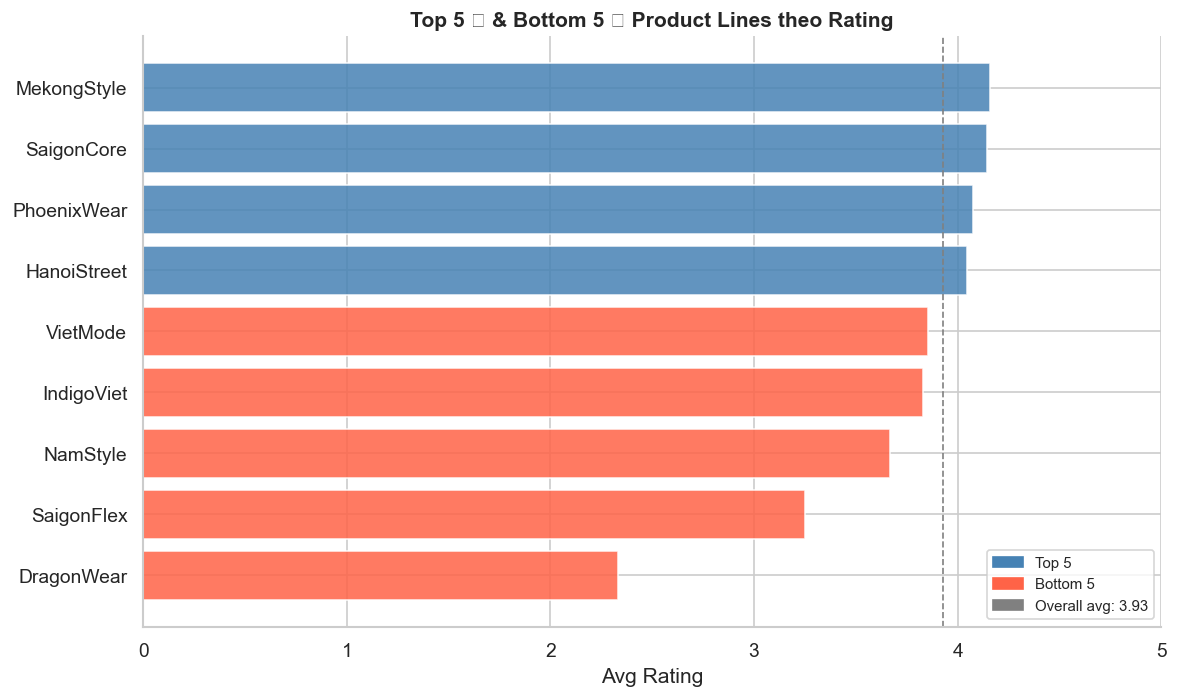

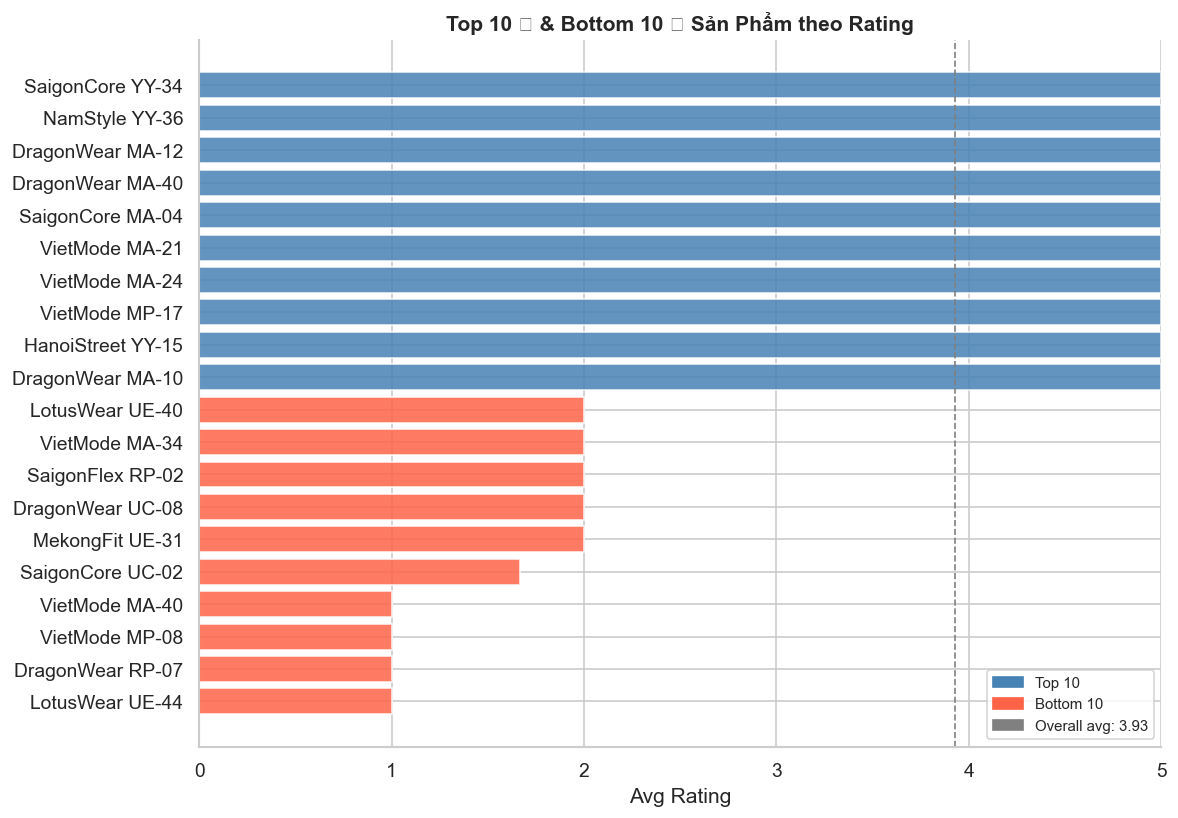

In [80]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Aggregate by product_line ─────────────────────────────────────────────────
prod_ratings_line = (
    reviews
    .merge(products[['product_id', 'product_line', 'category']], on='product_id')
    .groupby(['category', 'product_line'])
    .agg(
        avg_rating = ('rating', 'mean'),
        n_reviews  = ('rating', 'count'),
        pct_5star  = ('rating', lambda x: (x == 5).mean()),
        pct_1star  = ('rating', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

# ── Aggregate by product_name ─────────────────────────────────────────────────
prod_ratings_name = (
    reviews
    .merge(products[['product_id', 'product_name', 'category']], on='product_id')
    .groupby(['category', 'product_name'])
    .agg(
        avg_rating = ('rating', 'mean'),
        n_reviews  = ('rating', 'count'),
        pct_5star  = ('rating', lambda x: (x == 5).mean()),
        pct_1star  = ('rating', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

overall_avg = prod_ratings_name['avg_rating'].mean()

def make_top_bottom_chart(ax, df, label_col, n, title):
    """Reusable top/bottom bar chart."""
    top = df.nlargest(n, 'avg_rating')
    bot = df.nsmallest(n, 'avg_rating')
    combined = pd.concat([top, bot]).drop_duplicates(label_col).sort_values('avg_rating')
    colors = combined[label_col].isin(top[label_col]).map(
        {True: 'steelblue', False: 'tomato'}
    )
    ax.barh(combined[label_col], combined['avg_rating'],
            color=colors, alpha=0.85)
    ax.axvline(overall_avg, color='gray', linestyle='--', linewidth=1)
    ax.set_xlim(0, 5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Avg Rating')
    ax.legend(handles=[
        mpatches.Patch(color='steelblue', label=f'Top {n}'),
        mpatches.Patch(color='tomato',    label=f'Bottom {n}'),
        mpatches.Patch(color='gray',      label=f'Overall avg: {overall_avg:.2f}'),
    ], fontsize=9)

# ── Figure 1: by product_line ─────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))
make_top_bottom_chart(ax1, prod_ratings_line, 'product_line', 5,
                      'Top 5 ⬆ & Bottom 5 ⬇ Product Lines theo Rating')
plt.tight_layout()
plt.show()

# ── Figure 2: by product_name ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 7))
make_top_bottom_chart(ax2, prod_ratings_name, 'product_name', 10,
                      'Top 10 ⬆ & Bottom 10 ⬇ Sản Phẩm theo Rating')
plt.tight_layout()
plt.show()

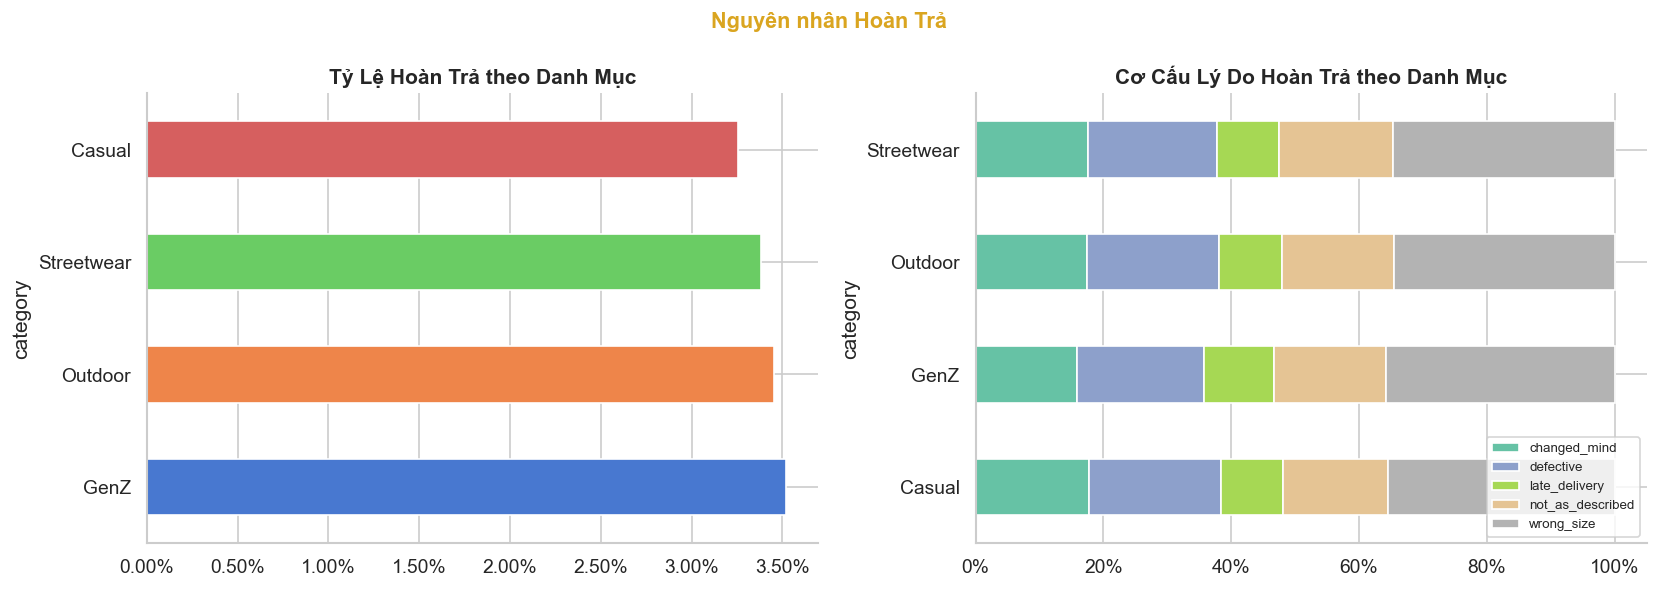

In [14]:
ret_enriched = (
    returns
    .merge(products[['product_id','category']], on='product_id')
    .merge(order_items[['order_id','product_id','quantity']],
           on=['order_id','product_id'], how='left')
)
sold_by_cat = (
    order_items
    .merge(products[['product_id','category']], on='product_id')
    .groupby('category')['quantity'].sum()
)
ret_by_cat = ret_enriched.groupby('category')['return_quantity'].sum()
ret_rate_cat = (ret_by_cat / sold_by_cat).sort_values(ascending=False)

reason_cat = (
    ret_enriched
    .groupby(['category','return_reason'])['return_quantity'].sum()
    .unstack('return_reason').fillna(0)
)
reason_cat_pct = reason_cat.div(reason_cat.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ret_rate_cat.plot.barh(ax=axes[0], color=PALETTE)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set_title('Tỷ Lệ Hoàn Trả theo Danh Mục', fontweight='bold')

reason_cat_pct.plot.barh(stacked=True, ax=axes[1],
                         colormap='Set2')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_title('Cơ Cấu Lý Do Hoàn Trả theo Danh Mục', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.suptitle('Nguyên nhân Hoàn Trả',
             fontsize=13, fontweight='bold', color='goldenrod')
plt.tight_layout()
plt.show()

Nhìn chung thì tỷ lệ hoàn hàng giữa các danh mục không có sự khác biệt rõ rệt. Lý do hoàn hàng chủ yếu thiên về đặc tính của sp (wrong size, defective,...) hơn là về giao hàng.

# 6. Sản phẩm và danh mục sản phẩm

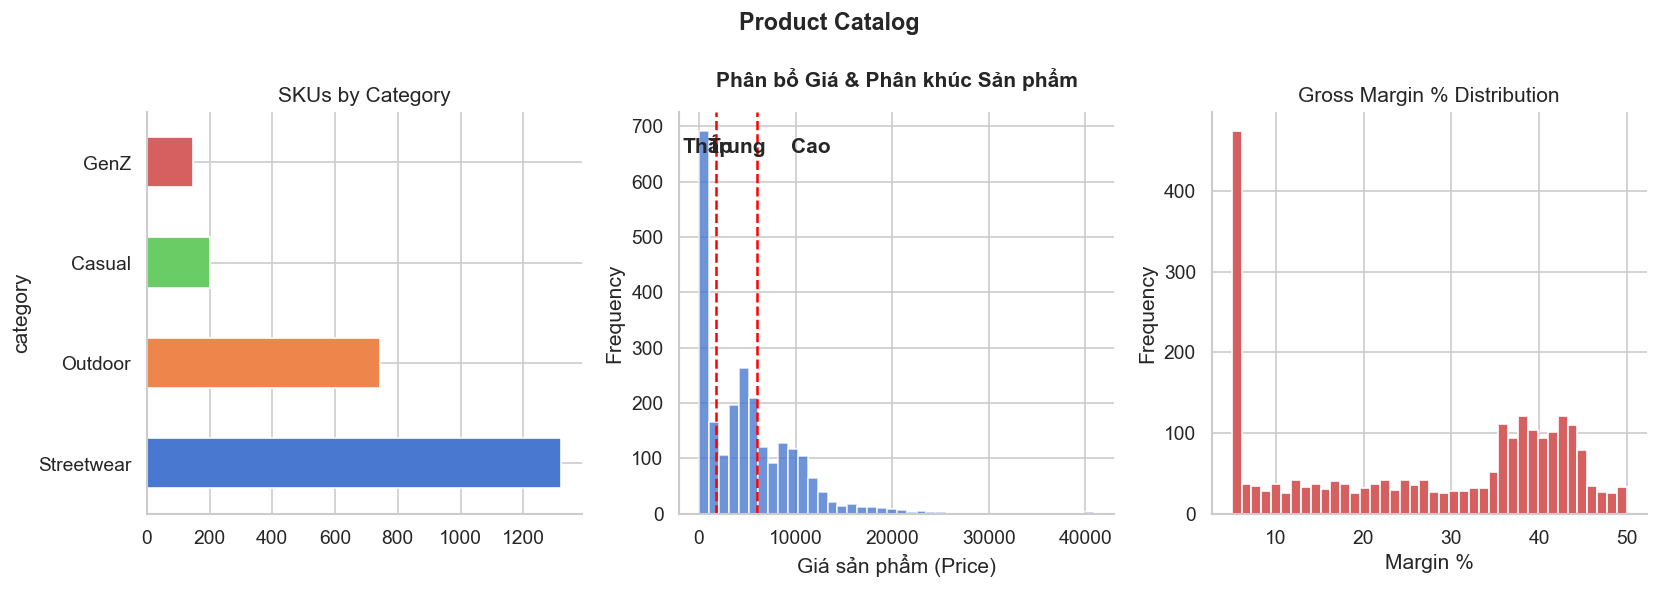

          price      cogs  margin_pct
count   2412.00   2412.00     2412.00
mean    4928.22   3868.35       26.59
std     4776.74   3878.58       15.11
min        9.06      5.18        5.00
25%       59.44     35.07       10.40
50%     4399.60   3184.93       30.58
75%     7720.51   5864.92       40.12
max    40950.00  38902.50       49.96


In [92]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Category breakdown
products['category'].value_counts().plot.barh(ax=axes[0], color=PALETTE)
axes[0].set_title('SKUs by Category')

# Price distribution
# 1. Tìm các mốc phân chia (cắt ở 33.3% và 66.7% dữ liệu)
p33 = products['price'].quantile(0.333)
p67 = products['price'].quantile(0.667)

# 2. Gán nhãn phân khúc trực tiếp vào Dataframe để tiện phân tích sau này
products['price_segment'] = pd.cut(
    products['price'], 
    bins=[0, p33, p67, float('inf')], 
    labels=['Thấp', 'Trung', 'Cao']
)

# 3. Vẽ biểu đồ Histogram (như cũ)
products['price'].plot.hist(bins=40, ax=axes[1], color=PALETTE[0], edgecolor='white', alpha=0.8)

# 4. Thêm đường cắt và Text chia vùng trên biểu đồ
axes[1].axvline(p33, color='red', linestyle='--', linewidth=1.5)
axes[1].axvline(p67, color='red', linestyle='--', linewidth=1.5)

# Tự động lấy chiều cao của biểu đồ để căn chỉnh chữ
y_max = axes[1].get_ylim()[1]
axes[1].text(p33 * 0.5, y_max * 0.9, f'Thấp', ha='center', fontweight='bold')
axes[1].text((p33 + p67) * 0.5, y_max * 0.9, f'Trung', ha='center', fontweight='bold')
axes[1].text(p67 + (products['price'].max()-p67)*0.1, y_max * 0.9, f'Cao', ha='left', fontweight='bold')

axes[1].set_title('Phân bổ Giá & Phân khúc Sản phẩm', fontweight='bold', pad=15)
axes[1].set_xlabel('Giá sản phẩm (Price)')

# Gross-margin proxy
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100
products['margin_pct'].plot.hist(bins=40, ax=axes[2], color=PALETTE[3], edgecolor='white')
axes[2].set_title('Gross Margin % Distribution')
axes[2].set_xlabel('Margin %')

plt.suptitle('Product Catalog', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(products[['price','cogs','margin_pct']].describe().round(2))

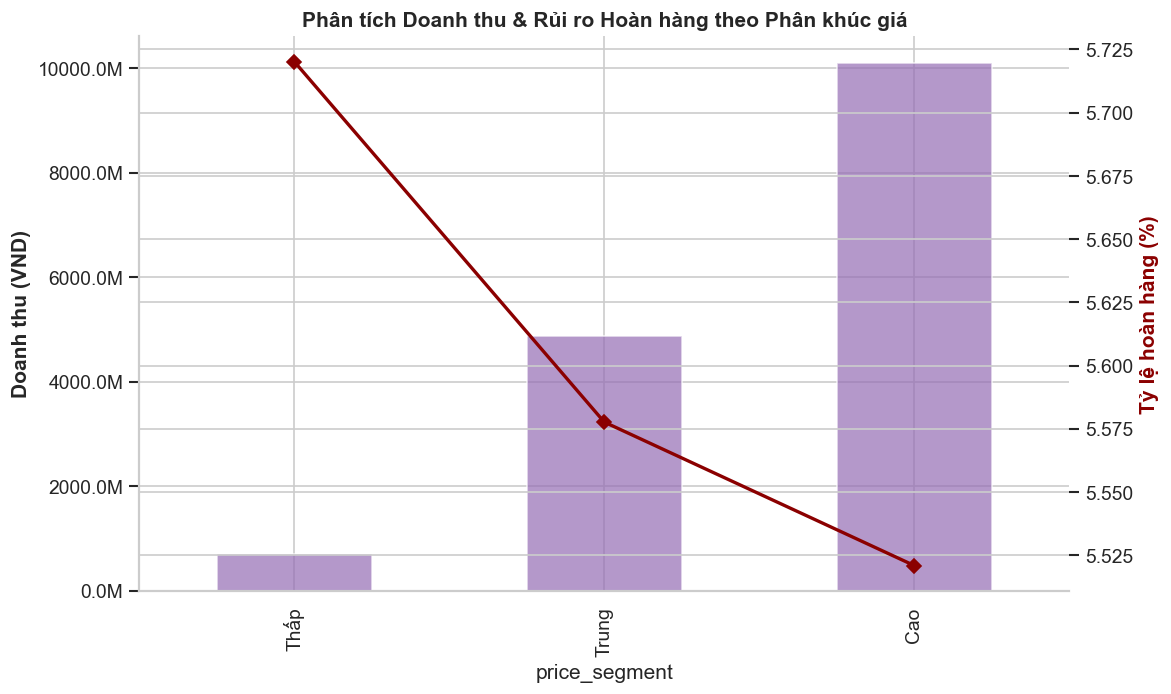

In [ ]:

returned_items = returns[['order_id', 'product_id']].drop_duplicates()
returned_items['is_returned'] = 1

# 2. Merge vào bảng order_items chính
df_analysis = (
    order_items
    .merge(products[['product_id', 'price_segment']], on='product_id')
    .merge(returned_items, on=['order_id', 'product_id'], how='left')
)

# Điền 0 cho những sản phẩm không nằm trong bảng returns
df_analysis['is_returned'] = df_analysis['is_returned'].fillna(0)

# 3. Tổng hợp dữ liệu theo Phân khúc
segment_stats = df_analysis.groupby('price_segment').agg(
    total_revenue=('line_rev', 'sum'),
    total_items=('order_id', 'count'),
    return_count=('is_returned', 'sum')
)

segment_stats['return_rate'] = (segment_stats['return_count'] / segment_stats['total_items']) * 100

# 4. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Doanh thu (Cột)
segment_stats['total_revenue'].plot(kind='bar', ax=ax1, color=PALETTE[4], alpha=0.7)
# Tỷ lệ hoàn hàng (Đường)
segment_stats['return_rate'].plot(kind='line', ax=ax2, color='darkred', marker='D', linewidth=2)

ax1.set_ylabel('Doanh thu (VND)', fontweight='bold')
ax2.set_ylabel('Tỷ lệ hoàn hàng (%)', color='darkred', fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title('Phân tích Doanh thu & Rủi ro Hoàn hàng theo Phân khúc giá', fontweight='bold')
plt.show()

Phân khúc sp giá cao lại có tỷ lệ hoàn hàng thấp hơn. 

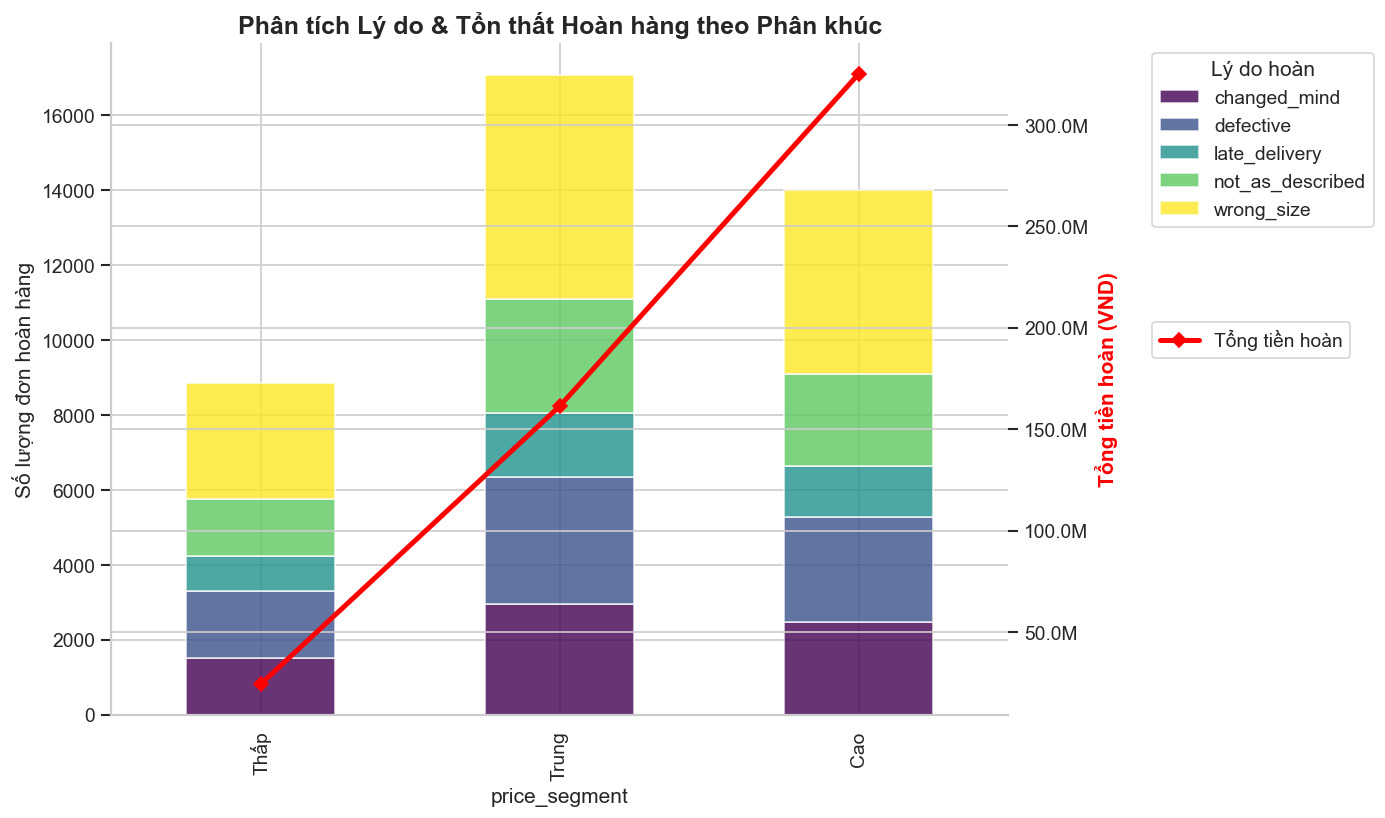

In [101]:
# 1. Tổng hợp dữ liệu chi tiết từ bảng returns
# Kết nối returns -> order_items (lấy segment) -> products
returns_detail = (
    returns.merge(order_items[['order_id', 'product_id', 'line_rev']], on=['order_id', 'product_id'])
    .merge(products[['product_id', 'price_segment']], on='product_id')
)

# 2. Tạo bảng pivot: Lý do hoàn theo phân khúc (tính theo số lượng đơn)
reason_pivot = returns_detail.pivot_table(
    index='price_segment', 
    columns='return_reason', 
    values='return_id', 
    aggfunc='count'
).reindex(['Thấp', 'Trung', 'Cao'])

# 3. Tính tổng tiền hoàn theo phân khúc
money_stats = returns_detail.groupby('price_segment')['refund_amount'].sum().reindex(['Thấp', 'Trung', 'Cao'])

# 4. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()

# Vẽ cột chồng (Lý do hoàn hàng)
reason_pivot.plot(kind='bar', stacked=True, ax=ax1, alpha=0.8, colormap='viridis')

# Vẽ đường tổng tiền hoàn (Refund Amount)
money_stats.plot(kind='line', ax=ax2, color='red', marker='D', linewidth=3, label='Tổng tiền hoàn')

# Tinh chỉnh giao diện
ax1.set_title('Phân tích Lý do & Tổn thất Hoàn hàng theo Phân khúc', fontweight='bold', fontsize=15)
ax1.set_ylabel('Số lượng đơn hoàn hàng')
ax2.set_ylabel('Tổng tiền hoàn (VND)', color='red', fontweight='bold')

# Định dạng tiền tệ cho trục phụ
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Đưa chú thích ra ngoài
ax1.legend(title='Lý do hoàn', bbox_to_anchor=(1.15, 1), loc='upper left')
ax2.legend(loc='upper left', bbox_to_anchor=(1.15, 0.6))

plt.tight_layout()
plt.show()

- Tổng số sp hoàn về ở tầm giá trung là nhiều nhất. 
- Tỷ lệ về lý do hoàn ở các phân khúc không có gì quá khác biệt. 

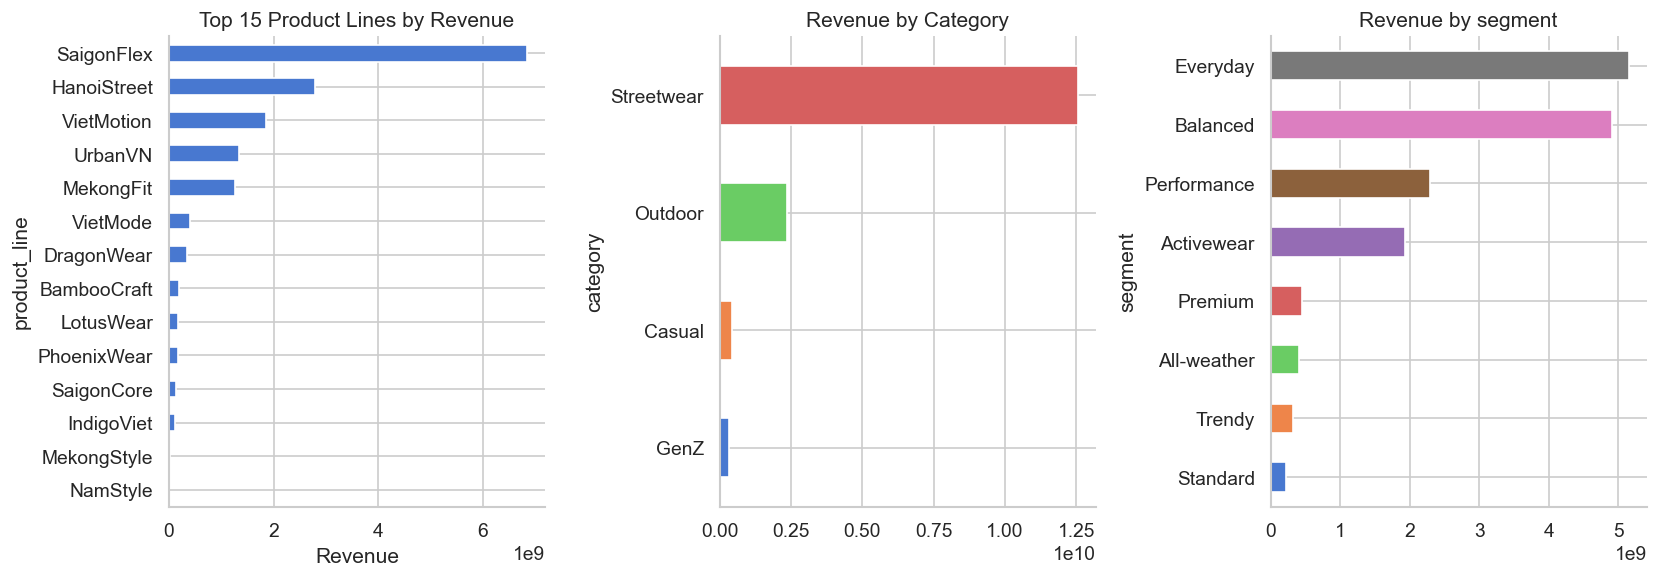

In [106]:
# Top products by revenue
item_rev = (
    order_items
    .assign(revenue=lambda x: x['unit_price'] * x['quantity'] - x['discount_amount'])
    .groupby('product_id')['revenue'].sum()
    .reset_index()
    .merge(products[['product_id','product_name', 'product_line', 'category', 'segment']], on='product_id')
    .sort_values('revenue', ascending=False)
)
top_line = (
    item_rev
    .groupby('product_line')['revenue'].sum()
    .reset_index()
    .sort_values('revenue', ascending=False)
)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

top_line.set_index('product_line')['revenue'].plot.barh(
    ax=axes[0], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Product Lines by Revenue')
axes[0].set_xlabel('Revenue')

# Revenue share by category
item_rev.groupby('category')['revenue'].sum().sort_values().plot.barh(
    ax=axes[1], color=PALETTE)
axes[1].set_title('Revenue by Category')

item_rev.groupby('segment')['revenue'].sum().sort_values().plot.barh(
    ax=axes[2], color=PALETTE)
axes[2].set_title('Revenue by segment')

plt.tight_layout()
plt.show()

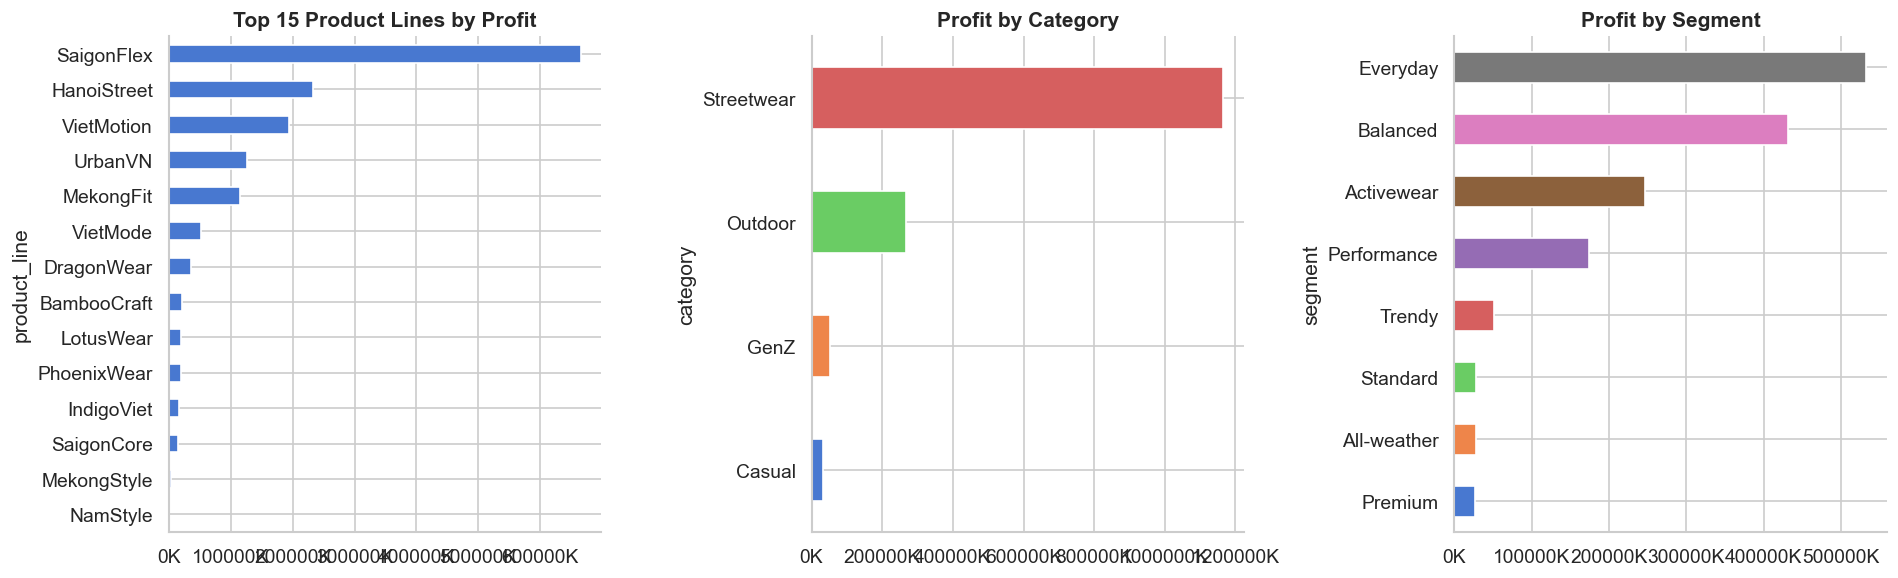

In [109]:
# 1. Tính toán Lợi nhuận (Profit) bằng cách merge order_items với products (lấy COGS)
item_profit = (
    order_items
    .merge(products[['product_id', 'product_name', 'product_line', 'category', 'segment', 'cogs']], on='product_id')
    .assign(
        revenue=lambda x: (x['unit_price'] * x['quantity']) - x['discount_amount'],
        total_cost=lambda x: x['cogs'] * x['quantity'],
        profit=lambda x: x['revenue'] - x['total_cost']
    )
    .groupby(['product_id', 'product_name', 'product_line', 'category', 'segment'])['profit'].sum()
    .reset_index()
    .sort_values('profit', ascending=False)
)

# 2. Groupby theo các chiều phân tích
line_profit = item_profit.groupby('product_line')['profit'].sum().sort_values(ascending=False)
cat_profit = item_profit.groupby('category')['profit'].sum().sort_values()
seg_profit = item_profit.groupby('segment')['profit'].sum().sort_values()

# 3. Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Lợi nhuận theo Line
line_profit.head(15).plot.barh(ax=axes[0], color=PALETTE[0])
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Product Lines by Profit', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Chart 2: Lợi nhuận theo Category
cat_profit.plot.barh(ax=axes[1], color=PALETTE)
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Chart 3: Lợi nhuận theo Segment
seg_profit.plot.barh(ax=axes[2], color=PALETTE)
axes[2].set_title('Profit by Segment', fontweight='bold')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.show()

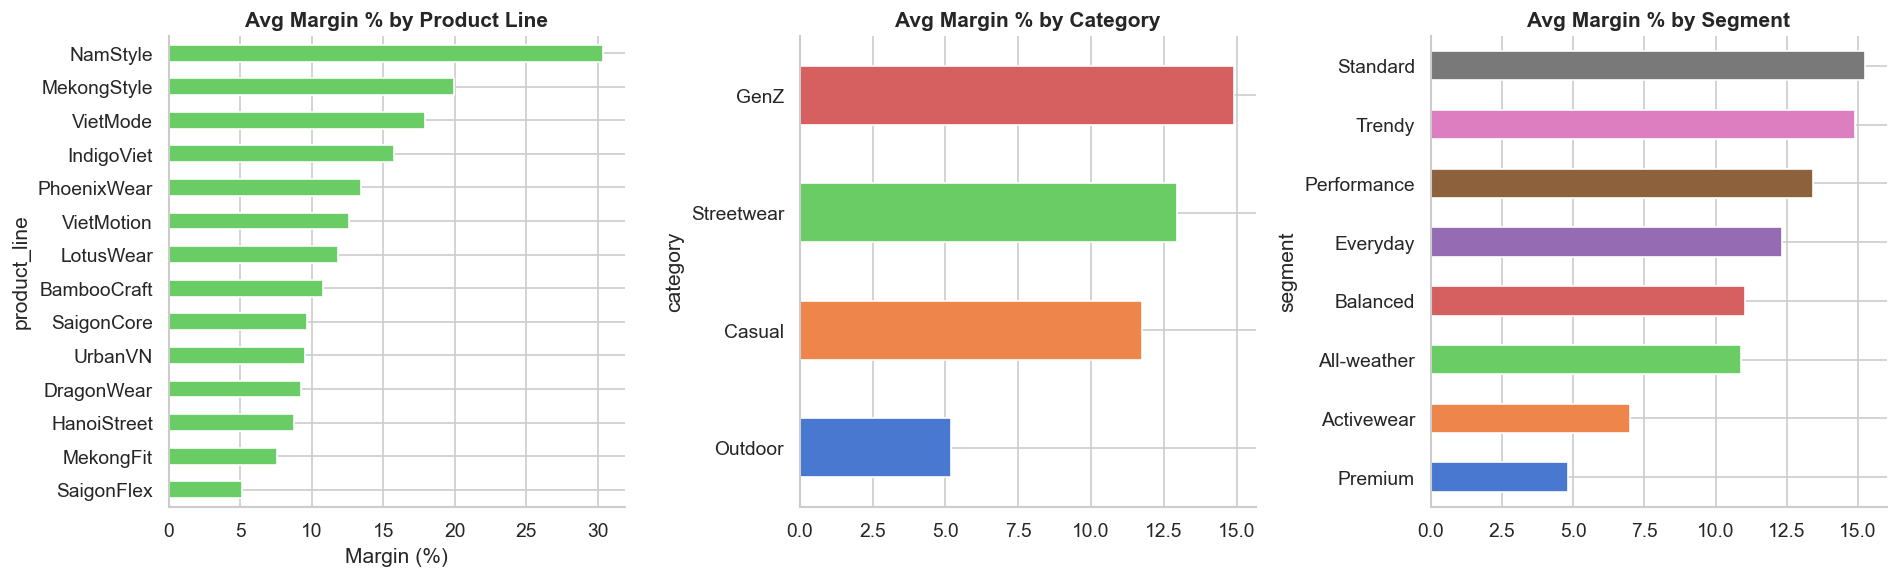

In [108]:
# 1. Tính toán lợi nhuận và biên lợi nhuận (%)
item_analysis = (
    order_items
    .merge(products[['product_id', 'product_name', 'product_line', 'category', 'segment', 'cogs']], on='product_id')
    .assign(
        revenue=lambda x: (x['unit_price'] * x['quantity']) - x['discount_amount'],
        total_cost=lambda x: x['cogs'] * x['quantity'],
        profit=lambda x: x['revenue'] - x['total_cost']
    )
    .groupby(['product_line', 'category', 'segment'])
    .agg(
        total_rev=('revenue', 'sum'),
        total_profit=('profit', 'sum')
    )
    .assign(margin_pct=lambda x: (x['total_profit'] / x['total_rev']) * 100)
    .reset_index()
)

# 2. Vẽ biểu đồ so sánh biên lợi nhuận (%)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Margin by Product Line (Top 15)
item_analysis.groupby('product_line')['margin_pct'].mean().sort_values(ascending=False).head(15).plot.barh(
    ax=axes[0], color=PALETTE[2])
axes[0].invert_yaxis()
axes[0].set_title('Avg Margin % by Product Line', fontweight='bold')
axes[0].set_xlabel('Margin (%)')

# Chart 2: Margin by Category
item_analysis.groupby('category')['margin_pct'].mean().sort_values().plot.barh(
    ax=axes[1], color=PALETTE)
axes[1].set_title('Avg Margin % by Category', fontweight='bold')

# Chart 3: Margin by Segment
item_analysis.groupby('segment')['margin_pct'].mean().sort_values().plot.barh(
    ax=axes[2], color=PALETTE)
axes[2].set_title('Avg Margin % by Segment', fontweight='bold')

plt.tight_layout()
plt.show()

Các hạng mục top thì gần như không thay đổi thứ tự giữa tổng doanh thu và lợi nhuận. SaigonFlex và HanoiStreet là hai dòng sản phẩm mang về nhiều tiền nhất cho công ty. Tuy nhiên, khi nhìn vào biểu đồ Biên lợi nhuận (Margin %), hai dòng này lại nằm ở nhóm cuối bảng. NamStyle và MekongStyle có biên lợi nhuận cực cao (lên đến 20-30%), nhưng đóng góp vào tổng lợi nhuận lại khá khiêm tốn.

# 7. Payments & Shipping

Median delivery days : 4
Orders not shipped   : 80,878


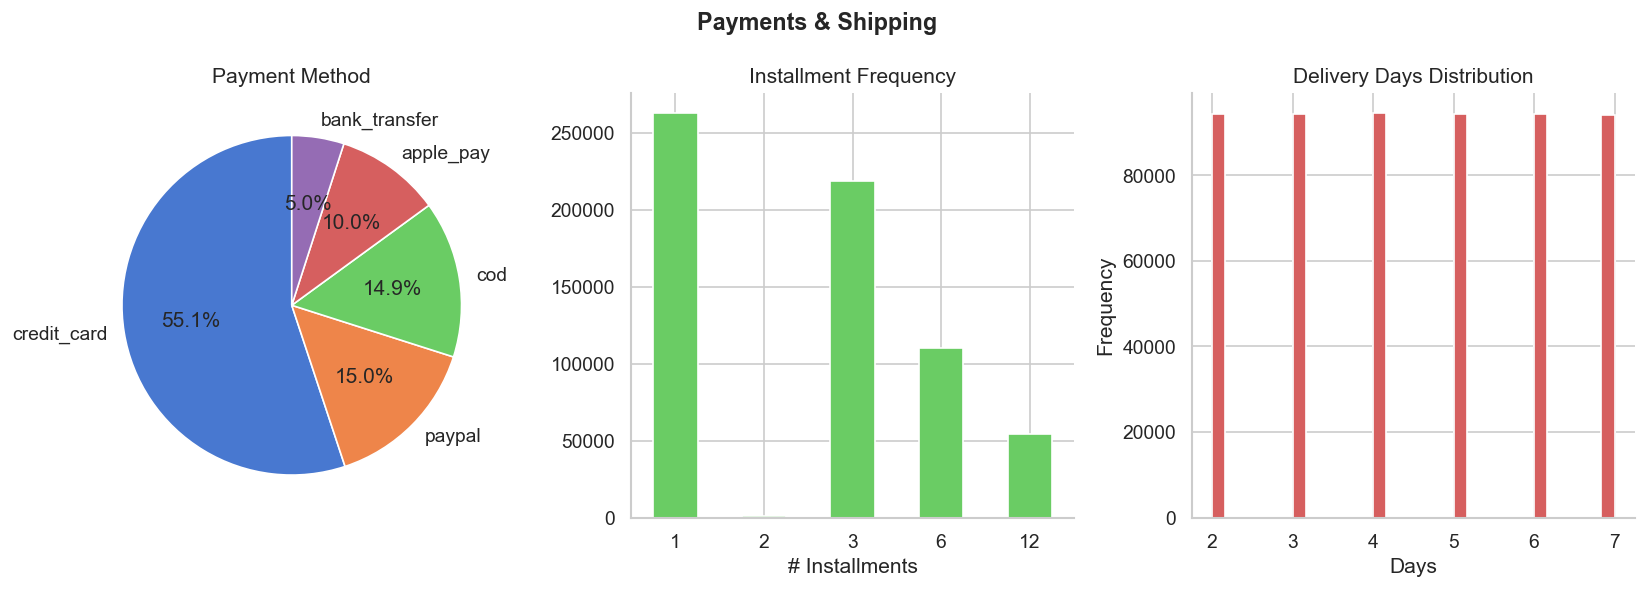

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Payment method split
payments['payment_method'].value_counts().plot.pie(
    ax=axes[0], autopct='%1.1f%%', startangle=90, colors=PALETTE)
axes[0].set_ylabel('')
axes[0].set_title('Payment Method')

# Installments distribution
payments['installments'].value_counts().sort_index().plot.bar(
    ax=axes[1], color=PALETTE[2], rot=0)
axes[1].set_title('Installment Frequency')
axes[1].set_xlabel('# Installments')

# Delivery time
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
shipments['delivery_days'].clip(lower=0, upper=30).plot.hist(
    bins=30, ax=axes[2], color=PALETTE[3], edgecolor='white')
axes[2].set_title('Delivery Days Distribution')
axes[2].set_xlabel('Days')

print(f"Median delivery days : {shipments['delivery_days'].median():.0f}")
print(f"Orders not shipped   : {orders.shape[0] - shipments.shape[0]:,}")

plt.suptitle('Payments & Shipping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Thanh toán không tiền mặt chiếm ưu thế, đb là credit card.   
Thanh toán 1 lần là phổ biến nhất. Khách hàng thích chia nhỏ các khoản thanh toán trong một quý hoặc nửa năm

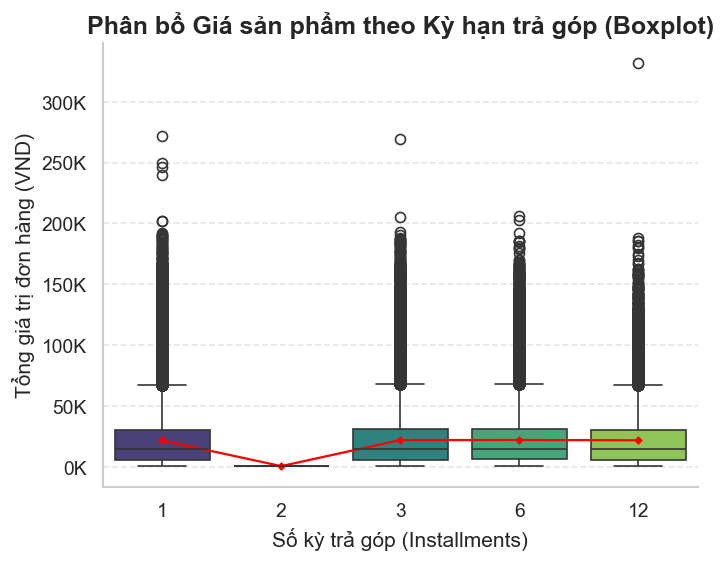

In [120]:
df_box = payments.merge(order_items[['order_id', 'line_rev']], on='order_id')
# showfliers=False để ẩn các điểm ngoại lai quá xa, giúp biểu đồ dễ nhìn hơn
# Bạn có thể đặt lại là True nếu muốn soi các đơn hàng "khủng"
sns.boxplot(data=df_box, x='installments', y='line_rev', 
            palette='viridis', showfliers=True)

# 3. Thêm điểm Mean (Trung bình) bằng hình kim cương đỏ để so sánh với Median
sns.pointplot(data=df_box, x='installments', y='line_rev', 
              color='red', markers='D', scale=0.5, errorbar=None)

# 4. Tinh chỉnh giao diện
plt.title('Phân bổ Giá sản phẩm theo Kỳ hạn trả góp (Boxplot)', fontweight='bold', fontsize=15)
plt.xlabel('Số kỳ trả góp (Installments)')
plt.ylabel('Tổng giá trị đơn hàng (VND)')

# Định dạng trục Y sang đơn vị nghìn (K)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Không thực sự có sự khác biệt đối với giá trị của đơn hàng với các kỳ trả góp khác nhau.

# 8. Web traffic

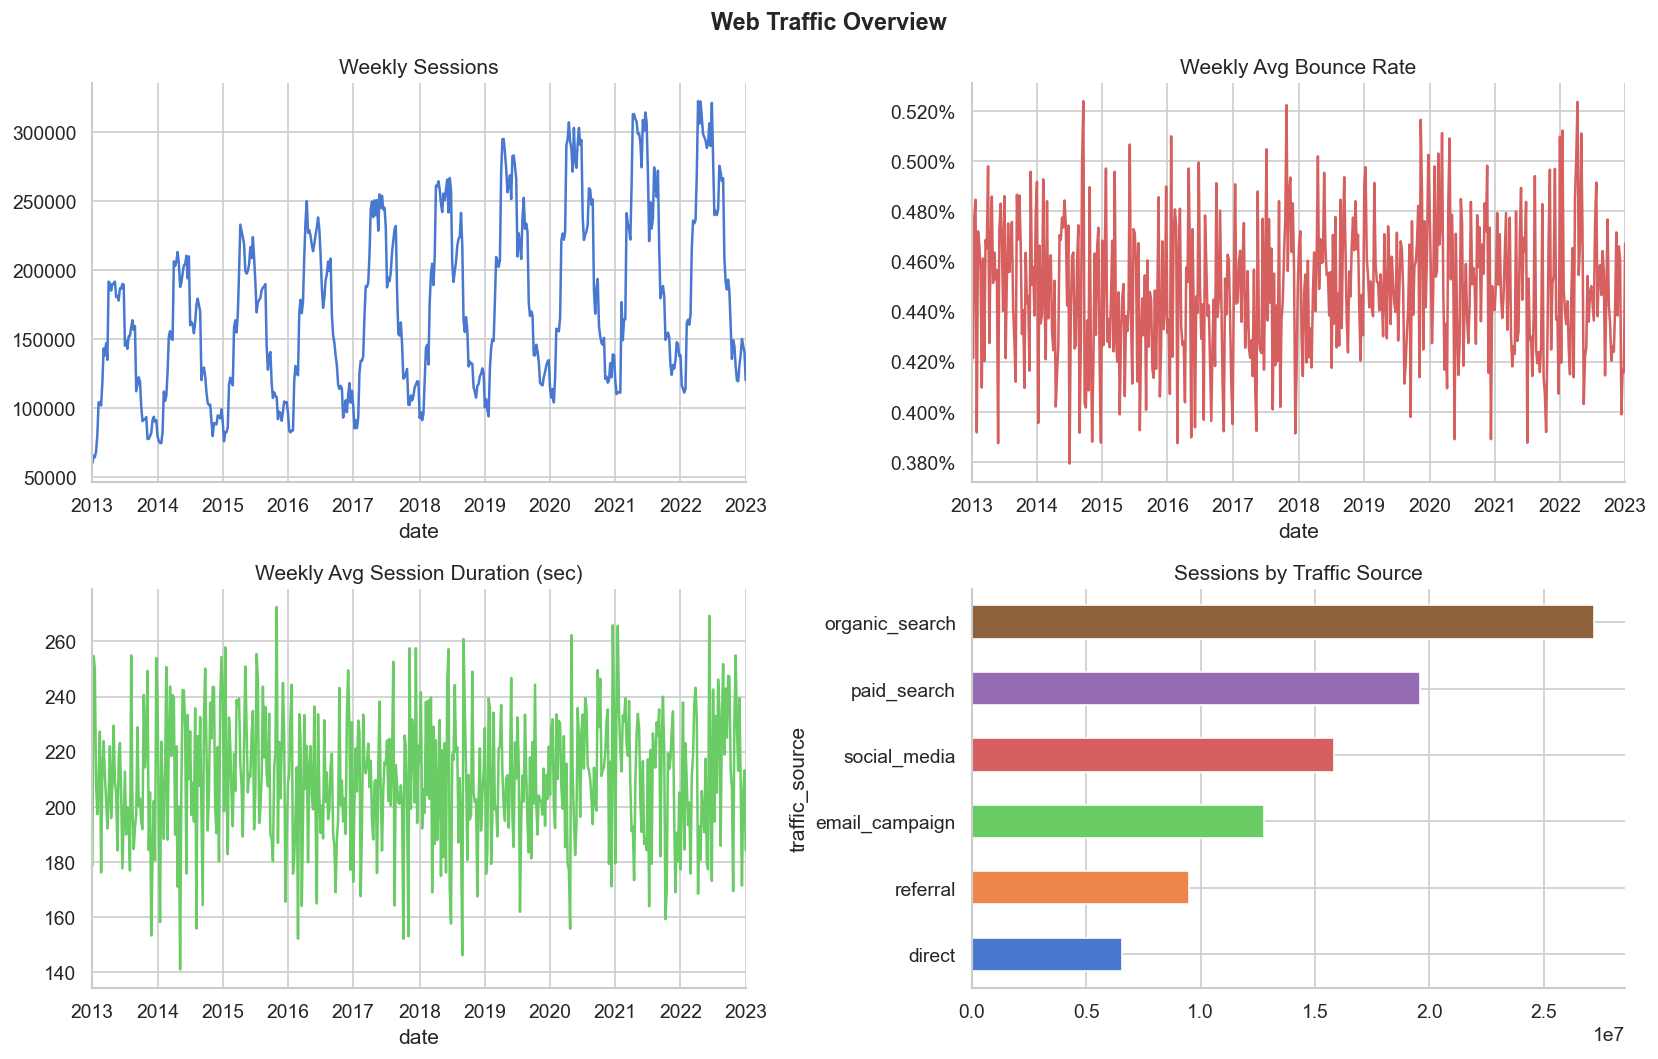

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

wt_daily = web_traffic.set_index('date')

wt_daily['sessions'].resample('W').sum().plot(
    ax=axes[0,0], color=PALETTE[0], linewidth=1.5)
axes[0,0].set_title('Weekly Sessions')

wt_daily['bounce_rate'].resample('W').mean().plot(
    ax=axes[0,1], color=PALETTE[3], linewidth=1.5)
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0,1].set_title('Weekly Avg Bounce Rate')

wt_daily['avg_session_duration_sec'].resample('W').mean().plot(
    ax=axes[1,0], color=PALETTE[2], linewidth=1.5)
axes[1,0].set_title('Weekly Avg Session Duration (sec)')

web_traffic.groupby('traffic_source')['sessions'].sum().sort_values().plot.barh(
    ax=axes[1,1], color=PALETTE)
axes[1,1].set_title('Sessions by Traffic Source')

plt.suptitle('Web Traffic Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Lượng truy cập có tính chu kỳ tương tự doanh thu nhưng có xu hướng tăng dần đều mặc dù dthu giảm ở giai đoạn 2019 đổ đi.  
Organic search cao -> SEO hiệu quả.

### P3. Chỉ Số Dẫn Xuất — Web Traffic → Đơn Hàng (Leading Indicator)

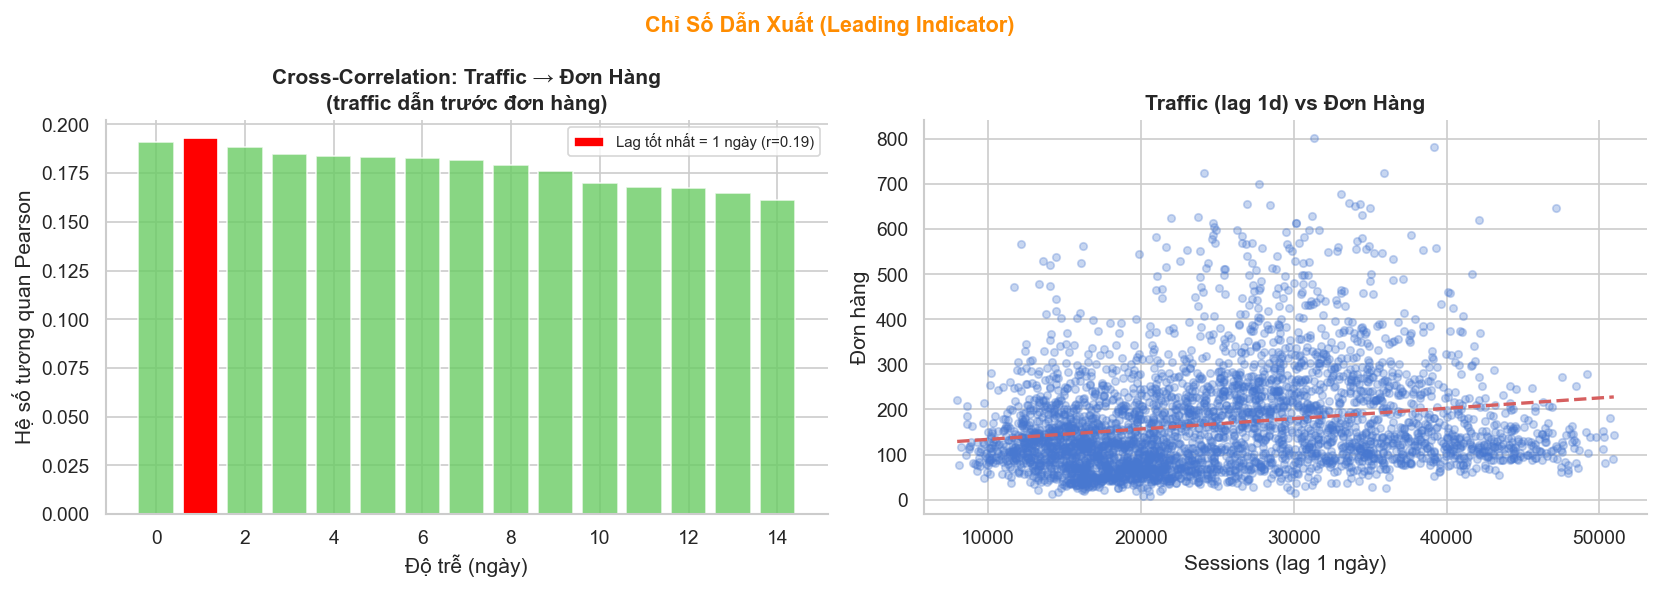


→ Traffic hôm nay dự báo đơn hàng sau 1 ngày
  Mỗi +100 sessions ≈ +0.2 đơn hàng


In [163]:
# Cross-correlation: traffic dẫn trước đơn hàng bao nhiêu ngày?
orders_daily = orders.groupby('order_date').size().rename('orders')
traffic_daily = web_traffic.set_index('date')['sessions']
aligned = pd.concat([orders_daily, traffic_daily], axis=1).dropna()

max_lag = 14
correlations = [
    aligned['sessions'].shift(lag).corr(aligned['orders'])
    for lag in range(0, max_lag+1)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(max_lag+1), correlations, color=PALETTE[2], alpha=0.8)
axes[0].set_xlabel('Độ trễ (ngày)')
axes[0].set_ylabel('Hệ số tương quan Pearson')
axes[0].set_title('Cross-Correlation: Traffic → Đơn Hàng\n(traffic dẫn trước đơn hàng)',
                  fontweight='bold')
best_lag = np.argmax(correlations)
axes[0].bar(best_lag, correlations[best_lag], color='red',
            label=f'Lag tốt nhất = {best_lag} ngày (r={correlations[best_lag]:.2f})')
axes[0].legend(fontsize=9)

# Scatter: traffic lag best → orders
aligned['traffic_lagged'] = aligned['sessions'].shift(best_lag)
aligned_clean = aligned.dropna()
axes[1].scatter(aligned_clean['traffic_lagged'], aligned_clean['orders'],
                alpha=0.3, color=PALETTE[0], s=20)
# Trend line
z = np.polyfit(aligned_clean['traffic_lagged'], aligned_clean['orders'], 1)
p = np.poly1d(z)
x_line = np.linspace(aligned_clean['traffic_lagged'].min(),
                     aligned_clean['traffic_lagged'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2)
axes[1].set_xlabel(f'Sessions (lag {best_lag} ngày)')
axes[1].set_ylabel('Đơn hàng')
axes[1].set_title(f'Traffic (lag {best_lag}d) vs Đơn Hàng', fontweight='bold')

plt.suptitle('Chỉ Số Dẫn Xuất (Leading Indicator)',
             fontsize=13, fontweight='bold', color='darkorange')
plt.tight_layout()
plt.show()

print(f'\n→ Traffic hôm nay dự báo đơn hàng sau {best_lag} ngày')
print(f'  Mỗi +100 sessions ≈ +{(z[0]*100):.1f} đơn hàng')

Tỷ lệ chuyển đổi thành đơn hàng của lượt truy cập tăng thêm thấp -> 1000 truy cập mới đc 2 đơn hàng. 

# 9. Inventory

Stockout rate         : 67.2%
Overstock rate        : 80.4%
Reorder rate          : 0.0%
Avg fill rate         : 96.1%
Avg DOS               : 378.4 days
Avg sell-through      : 11.8%


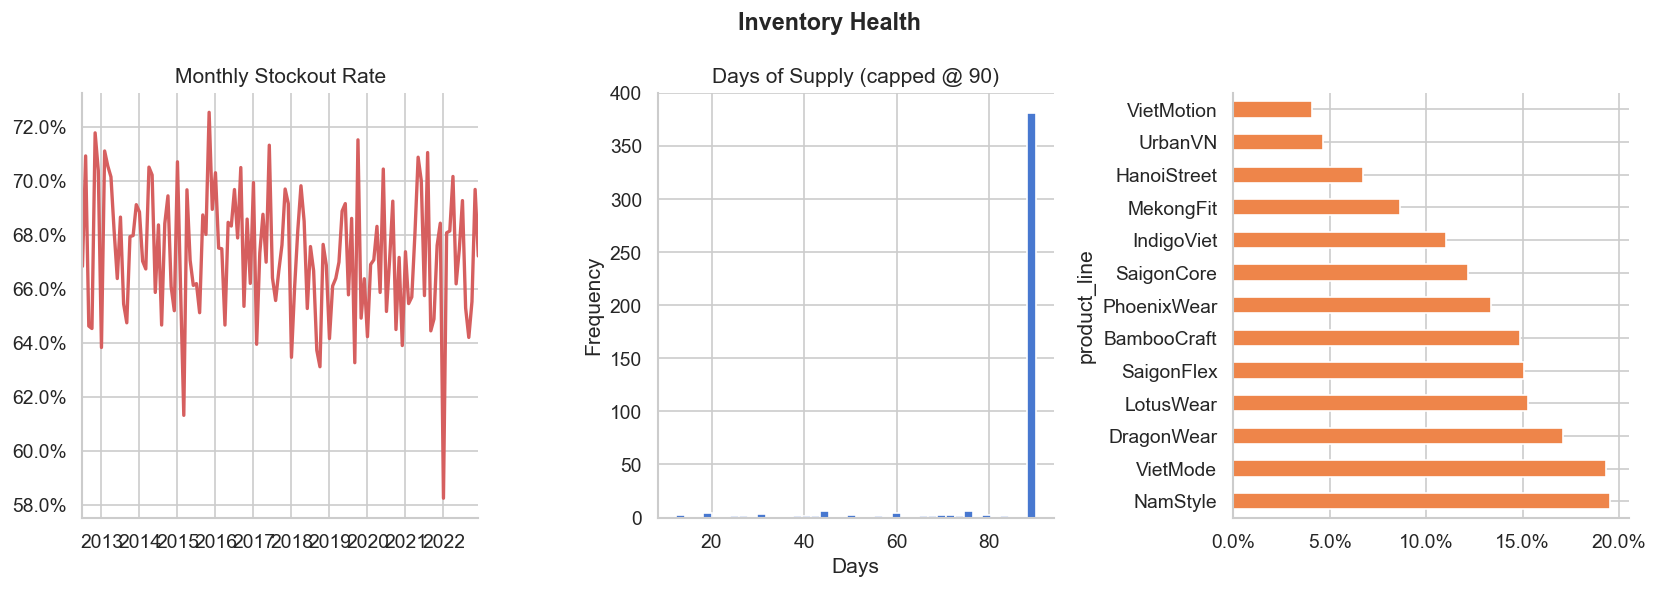

In [127]:
# Latest snapshot
latest_inv = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]

kpis = {
    'Stockout rate'   : f"{latest_inv['stockout_flag'].mean():.1%}",
    'Overstock rate'  : f"{latest_inv['overstock_flag'].mean():.1%}",
    'Reorder rate'    : f"{latest_inv['reorder_flag'].mean():.1%}",
    'Avg fill rate'   : f"{latest_inv['fill_rate'].mean():.1%}",
    'Avg DOS'         : f"{latest_inv['days_of_supply'].median():.1f} days",
    'Avg sell-through': f"{latest_inv['sell_through_rate'].mean():.1%}",
}
for k, v in kpis.items():
    print(f'{k:<22}: {v}')
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Stockout trend
inv_monthly = inventory.groupby('snapshot_date')['stockout_flag'].mean()
inv_monthly.plot(ax=axes[0], color=PALETTE[3], linewidth=2)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[0].set_title('Monthly Stockout Rate')
axes[0].set_xlabel('')

# Days of supply
latest_inv['days_of_supply'].clip(upper=90).plot.hist(
    bins=40, ax=axes[1], color=PALETTE[0], edgecolor='white')
axes[1].set_title('Days of Supply (capped @ 90)')
axes[1].set_xlabel('Days')

# Sell-through by product (top 20)
top_st = (
    latest_inv.merge(products[['product_id', 'product_line']], on='product_id')
    .set_index('product_line')['sell_through_rate']
    .groupby('product_line')
    .mean()
    .sort_values(ascending=False) )           

top_st.plot.barh(ax=axes[2], color=PALETTE[1])
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[2].set

plt.suptitle('Inventory Health', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Vừa thừa hàng vừa thiếu hàng nghiêm trọng. Avg DOS = 378.4 ngày, trung bình mất hơn 1 năm để bán hết lượng hàng trong kho.  
-> Thiếu những thứ khách cần và thừa những thứ khách không mua. 
Trong khi kho đầy hàng không bán được, thì những mặt hàng khách muốn mua lại đang bị cháy hàng tới hơn 2/3 thời gian.

Sell-through rate ~ 12% -> nhập 100 món thì bán đc 12 món. 
Dòng sp chủ lực như SaigonFlex và HanoiStreet sell-through rate thấp.

# 10. Phân loại dòng sp

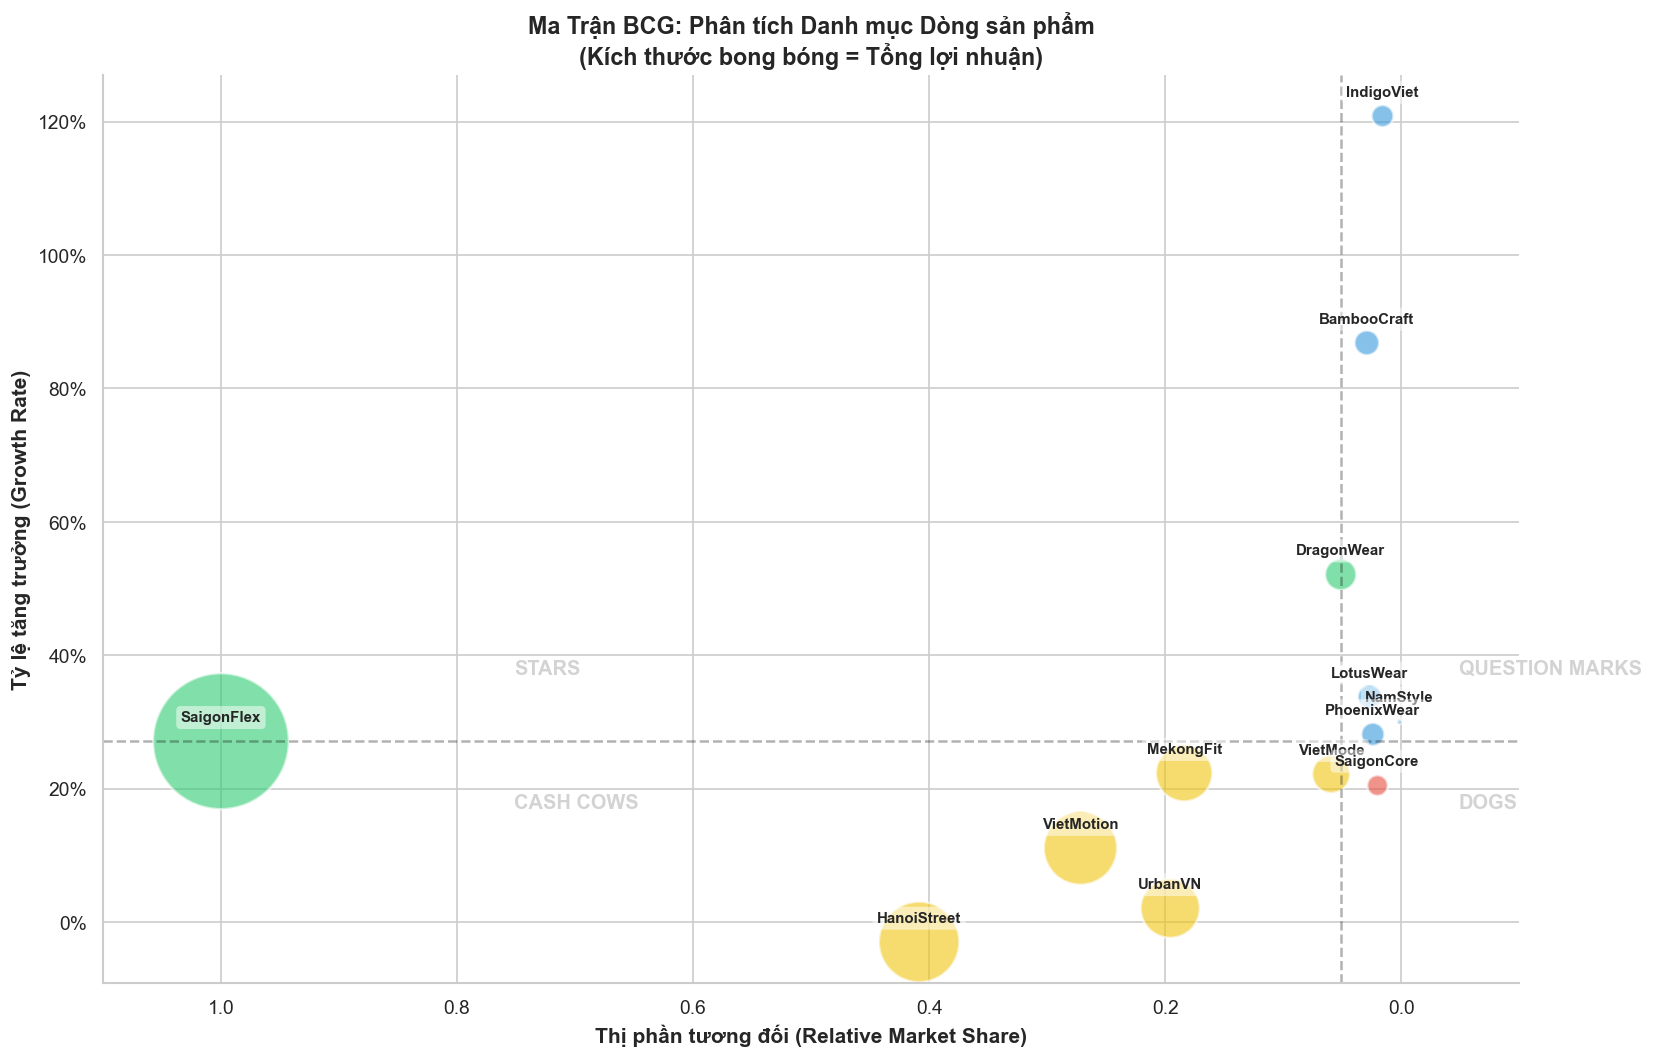

In [153]:
# 1. Chuẩn bị dữ liệu cấp Dòng sản phẩm (Product Line)
# Tính doanh thu theo năm/tháng để tính tăng trưởng (Growth)
order_items['year'] = pd.to_datetime(orders['order_date']).dt.year
line_yearly = (
    order_items.merge(products[['product_id', 'product_line']], on='product_id')
    .groupby(['product_line', 'year'])['line_rev'].sum()
    .unstack()
)

# Tính Growth Rate (ví dụ từ 2021 đến 2022)
growth_rate = ((line_yearly[2022] - line_yearly[2021]) / line_yearly[2021])

# Tính Market Share tương đối (So với dòng đứng đầu)
line_total_rev = order_items.merge(products[['product_id', 'product_line']], on='product_id').groupby('product_line')['line_rev'].sum()
relative_market_share = line_total_rev / line_total_rev.max()

# Tính Lợi nhuận tổng để làm kích thước bong bóng
line_profit = (
    order_items.merge(products[['product_id', 'product_line', 'cogs']], on='product_id')
    .assign(profit = lambda x: x['line_rev'] - (x['cogs'] * x['quantity']))
    .groupby('product_line')['profit'].sum()
)

# 2. Xây dựng BCG DataFrame
bcg_df = pd.DataFrame({
    'relative_share': relative_market_share,
    'growth_rate': growth_rate,
    'total_profit': line_profit
}).dropna()

# 3. Phân loại Quadrant theo chuẩn BCG
# Ngưỡng trung bình (Median) hoặc ngưỡng cố định (ví dụ 10% cho growth)
share_cutoff = bcg_df['relative_share'].median()
growth_cutoff = bcg_df['growth_rate'].median()

def classify_bcg(row):
    if row['growth_rate'] >= growth_cutoff and row['relative_share'] >= share_cutoff:
        return 'Stars'
    elif row['growth_rate'] < growth_cutoff and row['relative_share'] >= share_cutoff:
        return 'Cash Cows'
    elif row['growth_rate'] >= growth_cutoff and row['relative_share'] < share_cutoff:
        return 'Question Marks'
    else:
        return 'Dogs'

bcg_df['quadrant'] = bcg_df.apply(classify_bcg, axis=1)

# 4. Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 9))
colors = {'Stars': '#2ecc71', 'Cash Cows': '#f1c40f', 'Question Marks': '#3498db', 'Dogs': '#e74c3c'}

for quad, grp in bcg_df.groupby('quadrant'):
    # Vẽ bong bóng
    scatter = ax.scatter(grp['relative_share'], grp['growth_rate'], 
                         s=grp['total_profit']/1e5, 
                         c=colors[quad], label=quad, alpha=0.6, 
                         edgecolors='white', linewidth=1.5)
    
    # Thêm tên dòng sản phẩm cho từng chấm
    for i, txt in enumerate(grp.index):
        ax.annotate(txt, 
                    (grp['relative_share'].iloc[i], grp['growth_rate'].iloc[i]),
                    xytext=(0, 10), # Đẩy chữ lên trên bong bóng 10 đơn vị
                    textcoords='offset points',
                    ha='center', 
                    va='bottom',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.5))

# Đảo ngược trục X theo đúng chuẩn BCG (Thị phần cao bên trái)
ax.set_xlim(1.1, -0.1) 

# Thêm đường phân cách trung bình
ax.axhline(growth_cutoff, color='black', linestyle='--', alpha=0.3)
ax.axvline(share_cutoff, color='black', linestyle='--', alpha=0.3)

ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.set_xlabel('Thị phần tương đối (Relative Market Share)', fontweight='bold')
ax.set_ylabel('Tỷ lệ tăng trưởng (Growth Rate)', fontweight='bold')
ax.set_title('Ma Trận BCG: Phân tích Danh mục Dòng sản phẩm\n(Kích thước bong bóng = Tổng lợi nhuận)', fontsize=14, fontweight='bold')

# Chú thích các vùng
ax.text(share_cutoff + 0.7, growth_cutoff + 0.1, 'STARS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff - 0.1, growth_cutoff + 0.1, 'QUESTION MARKS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff + 0.7, growth_cutoff - 0.1, 'CASH COWS', fontsize=12, fontweight='bold', alpha=0.2)
ax.text(share_cutoff - 0.1, growth_cutoff - 0.1, 'DOGS', fontsize=12, fontweight='bold', alpha=0.2)


plt.tight_layout()
plt.show()

In [154]:
bcg_df

,relative_share,growth_rate,total_profit,quadrant
product_line,,,,
BambooCraft,0.029235,0.868458,2.187252e+07,Question Marks
DragonWear,0.051382,0.521165,3.518004e+07,Stars
HanoiStreet,0.408546,-0.029556,2.331058e+08,Cash Cows
IndigoViet,0.015912,1.208441,1.715030e+07,Question Marks
LotusWear,0.026787,0.337894,2.020379e+07,Question Marks
MekongFit,0.183980,0.223436,1.146828e+08,Cash Cows
NamStyle,0.001522,0.300871,9.992349e+05,Question Marks
PhoenixWear,0.024126,0.281626,1.900830e+07,Question Marks
SaigonCore,0.020559,0.205849,1.534424e+07,Dogs


- CASH COWS (Bò sữa): HanoiStreet, VietMotion, MekongFit, UrbanVN tạo ra lợi nhuận cao nhưng ở vùng tăng trưởng thấp. Tuy nhiên, HanoiStreet có mức tăng trưởng gần như đi ngang (-2.955%), cho thấy dòng này đang dần bão hòa.
- STARS (Ngôi sao): 
    - SaigonFlex - dòng đứng đầu với thị phần cao nhất và bong bóng lợi nhuận khổng lồ, đây là nguồn dòng tiền chính + tăng trưởng đạt ~ 27%. 
    - DragonWear đang xuất hiện ở vùng này với mức tăng trưởng ấn tượng (>50%) nhưng thị trường tương đối nhỏ. 
- QUESTION MARKS (Dấu hỏi):
    - IndigoViet và BambooCraft đang có tốc độ tăng trưởng từ 80% đến hơn 120% nhưng thị phần còn rất nhỏ. Đây là những dòng tiềm năng nhất để đầu tư Marketing nhằm chiếm lĩnh thị phần.

- DOGS (Chó mực): SaigonCore nằm sát vùng nguy hiểm với thị phần thấp và tăng trưởng thấp.


### PR2. Định Lượng Đánh Đổi — Chiết Khấu Promo vs Doanh Thu Tăng Thêm

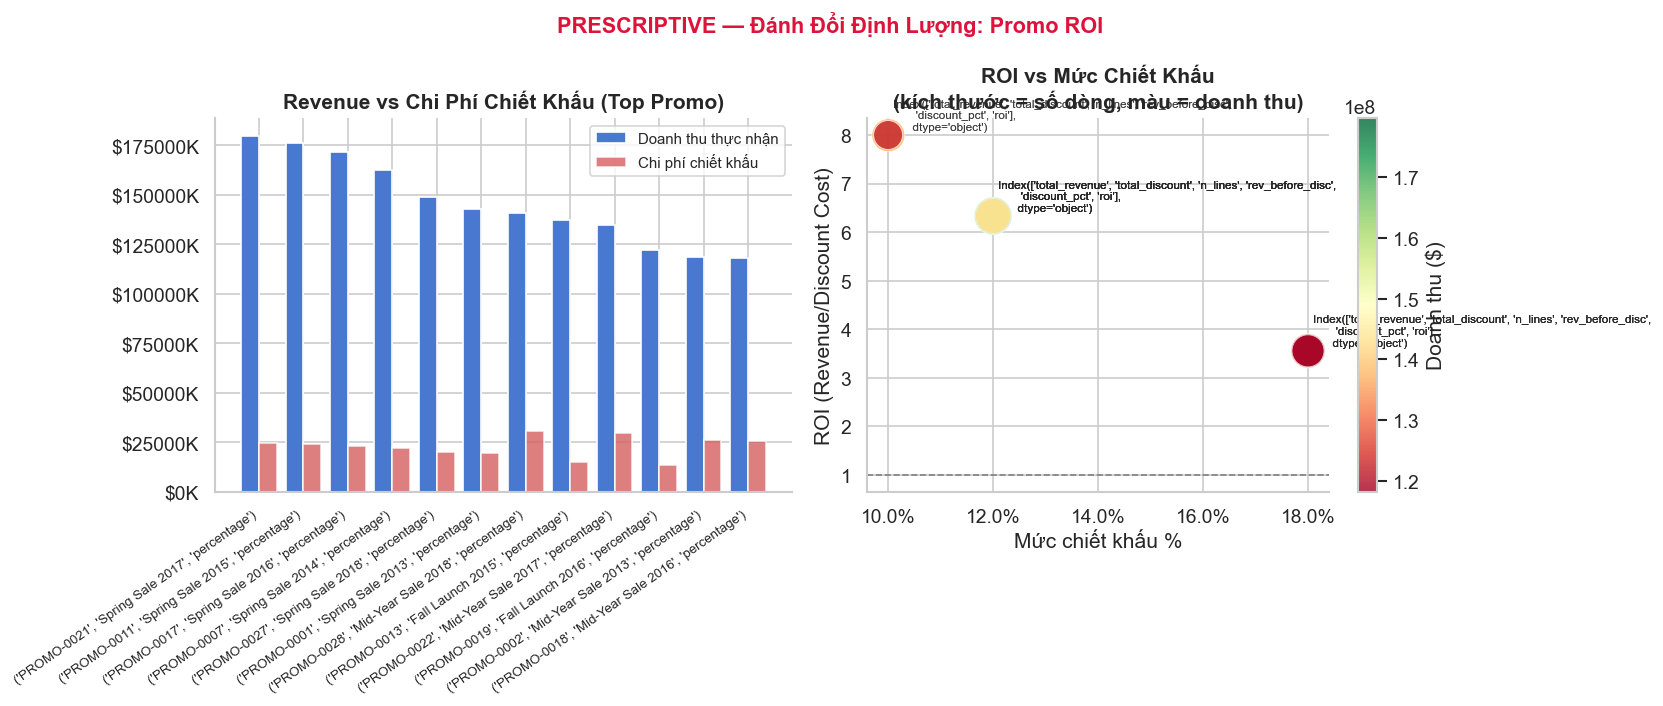


Tóm tắt Promo ROI (Top 10):
                                          total_revenue  total_discount  discount_pct       roi
promo_id   promo_name         promo_type                                                       
PROMO-0021 Spring Sale 2017   percentage   1.797860e+08     24516277.20      0.120000  6.333333
PROMO-0011 Spring Sale 2015   percentage   1.762220e+08     24030267.10      0.120000  6.333333
PROMO-0017 Spring Sale 2016   percentage   1.715650e+08     23395224.25      0.120000  6.333333
PROMO-0007 Spring Sale 2014   percentage   1.626504e+08     22179596.04      0.120000  6.333333
PROMO-0027 Spring Sale 2018   percentage   1.489566e+08     20312267.10      0.120000  6.333333
PROMO-0001 Spring Sale 2013   percentage   1.426156e+08     19447576.15      0.120000  6.333333
PROMO-0028 Mid-Year Sale 2018 percentage   1.407959e+08     30906414.14      0.180000  3.555556
PROMO-0013 Fall Launch 2015   percentage   1.375168e+08     15286980.12      0.100043  7.995682
PROMO-0022 

In [ ]:
# Tính incremental revenue và cost of discount theo promo
promo_perf = (
    order_items[order_items['promo_id'].notna()]
    .merge(promotions[['promo_id','promo_name','promo_type']], on='promo_id', how='left')
    .groupby(['promo_id','promo_name','promo_type'])
    .agg(
        total_revenue   = ('line_rev',        'sum'),
        total_discount  = ('discount_amount',  'sum'),
        n_lines         = ('order_id',         'count'),
    )
    .assign(
        rev_before_disc = lambda x: x['total_revenue'] + x['total_discount'],
        discount_pct    = lambda x: x['total_discount'] / x['rev_before_disc'],
        roi             = lambda x: (x['total_revenue'] - x['total_discount']) / x['total_discount']
    )
    .sort_values('total_revenue', ascending=False)
)

top_promos = promo_perf.head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grouped bar: revenue vs discount
x = np.arange(len(top_promos))
w = 0.4
axes[0].bar(x - w/2, top_promos['total_revenue']/1e3,   width=w,
            label='Doanh thu thực nhận', color=PALETTE[0])
axes[0].bar(x + w/2, top_promos['total_discount']/1e3, width=w,
            label='Chi phí chiết khấu', color=PALETTE[3], alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_promos.index, rotation=35, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))
axes[0].set_title('Revenue vs Chi Phí Chiết Khấu (Top Promo)', fontweight='bold')
axes[0].legend(fontsize=9)

# ROI scatter
sc = axes[1].scatter(top_promos['discount_pct'], top_promos['roi'],
                     s=top_promos['n_lines']/top_promos['n_lines'].max()*500,
                     c=top_promos['total_revenue'], cmap='RdYlGn',
                     alpha=0.8, edgecolors='white', linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label='Doanh thu ($)')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1))
axes[1].set_xlabel('Mức chiết khấu %')
axes[1].set_ylabel('ROI (Revenue/Discount Cost)')
axes[1].set_title('ROI vs Mức Chiết Khấu\n(kích thước = số dòng, màu = doanh thu)',
                  fontweight='bold')
for _, row in top_promos.iterrows():
    axes[1].annotate(row.index[:12],
                     (row['discount_pct'], row['roi']),
                     fontsize=7, alpha=0.7,
                     xytext=(3, 3), textcoords='offset points')

plt.suptitle('Đánh Đổi: Promo ROI',
             fontsize=13, fontweight='bold', color='crimson')
plt.tight_layout()
plt.show()

print('\nTóm tắt Promo ROI (Top 10):')
print(promo_perf[['total_revenue',
                  'total_discount','discount_pct','roi']]
      .head(10).to_string(index=True))

### PR3. Đề Xuất Hành Động — Inventory Reorder Priorities

In [162]:


# # Kết hợp inventory health + revenue để ưu tiên tái đặt hàng
# latest_inv = inventory[inventory['snapshot_date'] == inventory['snapshot_date'].max()]
# inv_action = (
#     latest_inv
#     .merge(products[['product_id','product_name', 'product_line', 'category']], on='product_id')
#     .merge(order_items[['product_id','line_rev']], on='product_id', how='left')
# )

# # Ưu tiên: Doanh thu cao + stockout hoặc reorder
# inv_action['priority_score'] = (
#     inv_action['line_rev'].fillna(0) / inv_action['line_rev'].max() * 0.6 +
#     inv_action['stockout_flag'] * 0.25 +
#     inv_action['reorder_flag']  * 0.15
# )
# inv_action['action'] = 'Theo dõi'
# inv_action.loc[inv_action['stockout_flag'] == 1, 'action'] = '🚨 Đặt hàng ngay'
# inv_action.loc[(inv_action['reorder_flag'] == 1) &
#                (inv_action['stockout_flag'] == 0), 'action'] = '⚠ Đặt hàng sớm'
# inv_action.loc[inv_action['overstock_flag'] == 1, 'action'] = '📦 Tồn kho cao - Đẩy hàng'

# top_urgent = inv_action[inv_action['action'].str.contains('Đặt hàng')]\
#              .nlargest(15, 'priority_score')

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Urgent reorder list
# color_map = {'🚨 Đặt hàng ngay': 'red', '⚠ Đặt hàng sớm': 'orange'}
# colors = top_urgent['action'].map(color_map).fillna('gray')
# bars = axes[0].barh(top_urgent.index, top_urgent['priority_score'],
#                     color=colors, alpha=0.85)
# axes[0].set_title('Top 15 Sản Phẩm Cần Đặt Hàng\n(ưu tiên = doanh thu × tình trạng tồn kho)',
#                   fontweight='bold')
# axes[0].set_xlabel('Priority Score')
# patches = [mpatches.Patch(color='red', label='🚨 Đặt hàng ngay'),
#            mpatches.Patch(color='orange', label='⚠ Đặt hàng sớm')]
# axes[0].legend(handles=patches, fontsize=9)

# # Action summary
# action_summary = inv_action['action'].value_counts()
# action_summary.plot.pie(ax=axes[1], autopct='%1.1f%%',
#                         colors=['red','orange','steelblue','lightgray'],
#                         startangle=90)
# axes[1].set_ylabel('')
# axes[1].set_title('Phân Loại Hành Động Tồn Kho', fontweight='bold')

# plt.suptitle('PRESCRIPTIVE — Ưu Tiên Hành Động Tồn Kho',
#              fontsize=13, fontweight='bold', color='crimson')
# plt.tight_layout()
# plt.show()

# print('\nTóm tắt hành động tồn kho:')
# print(action_summary.to_string())